# Naive Bayes (Gaussian, Multinomial & Bernoulli)

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)

> **Scope**: the from-scratch twin in `src/models/naive_bayes_models.py` implements the **Gaussian** variant only (`GaussianNaiveBayesScratch`). The count-based text variants (`MultinomialNB`, `BernoulliNB`, `ComplementNB`) are shown in §6, §7 and §10 using scikit-learn only.

---

## 1. Introduction

### What is Naive Bayes?

Naive Bayes is a **probabilistic generative** classifier. Instead of learning where the boundary between classes sits, it models **how each class generates the features**, then uses Bayes' rule to ask: given these feature values, which class most likely produced them?

$$P(y \mid x) \propto P(y) \prod_{j=1}^{d} P(x_j \mid y)$$

The **"naive"** part is the assumption that features are **conditionally independent given the class**, so the joint likelihood factorises into a plain product of one-feature terms. That assumption is almost never true in practice, and yet the classifier keeps working — a famous result we will demonstrate directly in §3 (Domingos & Pazzani 1997).

**Key characteristics:**
- **Generative**: models $P(x \mid y)$ explicitly — you can even sample new data from the fitted model (§6)
- **One-pass, closed form**: fit is counting and averaging; no iterative solver, no learning rate, no convergence
- **Scale-invariant** (Gaussian): per-feature means and variances absorb any feature scale — no scaler needed
- **Native probabilities**: `predict_proba` comes straight from Bayes' rule — but it is often overconfident when features correlate (§3, §10)
- **Linear cost**: trains in $O(n \cdot d)$, predicts in $O(d \cdot C)$ per sample
- **A family, not one algorithm**: Gaussian (continuous), Multinomial (counts), Bernoulli (binary), Categorical (integer codes) — the variant must match the feature type

**Historical Context:**
- Bayes (1763): "An Essay towards Solving a Problem in the Doctrine of Chances" — the theorem underneath everything
- John & Langley (1995): "Estimating Continuous Distributions in Bayesian Classifiers" — the per-feature Gaussian estimation used today
- Domingos & Pazzani (1997): "On the Optimality of the Simple Bayesian Classifier" — why naive Bayes stays near-optimal on 0-1 loss even when independence fails
- McCallum & Nigam (1998): the event-model comparison that made Multinomial NB the standard for text
- The 1990s: Naive Bayes and logistic regression were the spam-filtering workhorses of the early internet

**Main Use Cases:**
- Text classification: spam filtering, topic tagging, language identification (§6's in-notebook corpus, §7's alpha sweep)
- Real-time or streaming scoring, where a one-pass fit and `partial_fit` matter
- Small-data baselines: dozens of rows per class are enough to fit
- High-dimensional problems where features outnumber samples
- The first model to fit on any new tabular problem — the floor every other model must beat

**How it works (simplified):**
1. Estimate one prior per class from the label frequencies
2. Estimate one distribution per feature per class (a Gaussian for continuous features)
3. Predict by comparing unnormalised log posteriors: log prior + one log-density term per feature
4. Do all of it in log space, because products of many small densities underflow

In [1]:
# Import necessary libraries
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import calibration_curve
from sklearn.datasets import (load_breast_cancer, load_digits, load_iris, make_blobs,
                              make_classification, make_moons)
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                             confusion_matrix, f1_score, log_loss, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully!
NumPy version: 2.5.1
Pandas version: 3.0.3


### Visual Intuition: One Gaussian per Feature, per Class

The model learns exactly three things per class: a prior, one mean per feature, one variance per feature. Left: those 1-D Gaussians for one feature. Right: their product — the class likelihood $P(x \mid y)$ — whose contours are always **ellipses aligned with the axes**. That alignment is the independence assumption drawn.

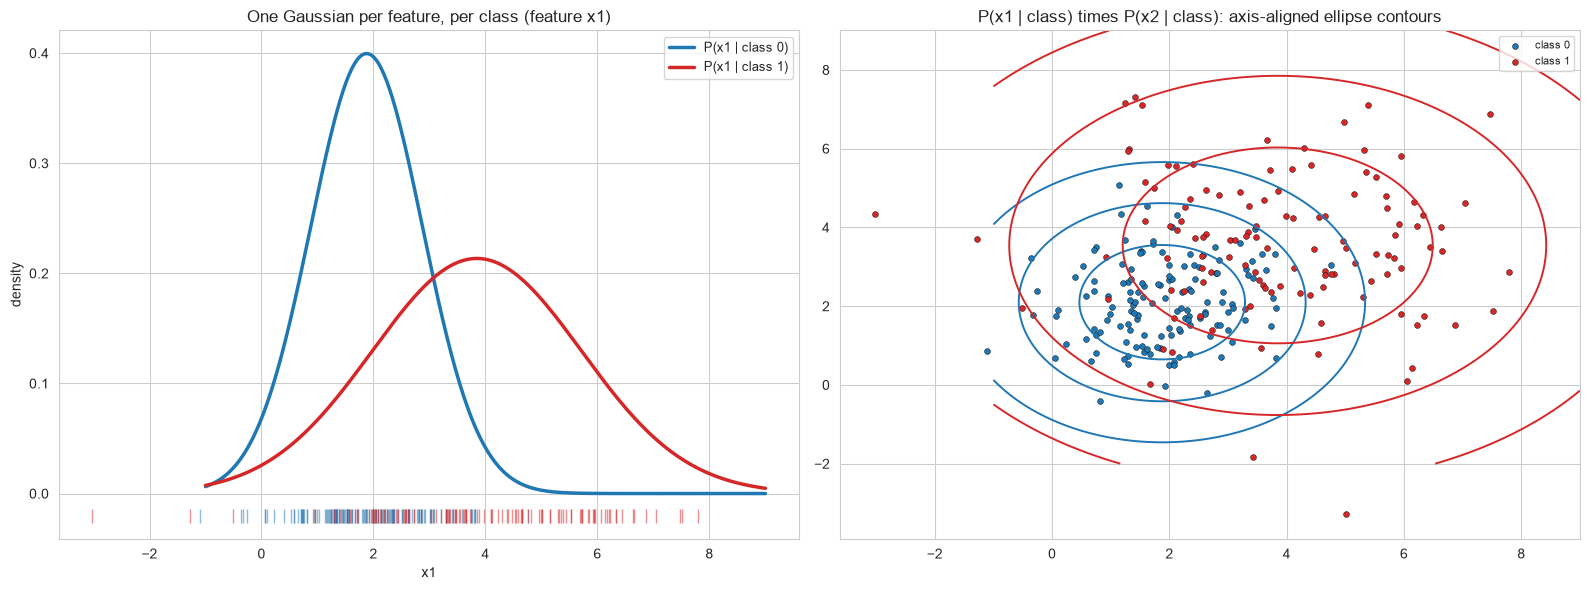

💡 Left: NB fits one bell curve per feature per class — that is all it learns. Right: the product
   of those bells is an ellipse aligned with the axes, because independence cannot represent tilts.
   Correlated features need tilted contours — you will see that gap on the moons data in §5.


In [2]:
rng_vis = np.random.default_rng(0)
X_vis = np.r_[rng_vis.normal([2.0, 2.0], 1.0, size=(140, 2)),
              rng_vis.normal([4.0, 3.5], 1.8, size=(120, 2))]
y_vis = np.r_[np.zeros(140, int), np.ones(120, int)]
nb_vis = GaussianNB().fit(X_vis, y_vis)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) One feature: the per-class 1-D Gaussians the model actually stores
xs_vis = np.linspace(-1.0, 9.0, 400)
for c, (cls, color) in enumerate(zip(nb_vis.classes_, ["#1f77b4", "#d62728"])):
    mu_v, var_v = nb_vis.theta_[c, 0], nb_vis.var_[c, 0]
    pdf_v = np.exp(-0.5 * (xs_vis - mu_v) ** 2 / var_v) / np.sqrt(2 * np.pi * var_v)
    axes[0].plot(xs_vis, pdf_v, color=color, lw=2.5, label=f"P(x1 | class {int(cls)})")
    axes[0].plot(X_vis[y_vis == cls, 0], np.full(int(np.sum(y_vis == cls)), -0.02), "|",
                 color=color, ms=10, alpha=0.5)
axes[0].set_xlabel("x1")
axes[0].set_ylabel("density")
axes[0].set_title("One Gaussian per feature, per class (feature x1)")
axes[0].legend(fontsize=9)

# (b) Two features: the product of the per-feature Gaussians
xx_v, yy_v = np.meshgrid(np.linspace(-1, 9, 300), np.linspace(-2, 9, 300))
grid_v = np.c_[xx_v.ravel(), yy_v.ravel()]
for c, (cls, color) in enumerate(zip(nb_vis.classes_, ["#1f77b4", "#d62728"])):
    log_pdf_v = (-0.5 * np.log(2 * np.pi * nb_vis.var_[c])
                 - (grid_v - nb_vis.theta_[c]) ** 2 / (2 * nb_vis.var_[c])).sum(axis=1)
    pdf_v = np.exp(log_pdf_v).reshape(xx_v.shape)
    axes[1].contour(xx_v, yy_v, pdf_v, levels=pdf_v.max() * np.exp([-6.0, -3.0, -1.0]),
                    colors=color, linewidths=1.4)
for label, color in zip(np.unique(y_vis), ["#1f77b4", "#d62728"]):
    axes[1].scatter(X_vis[y_vis == label, 0], X_vis[y_vis == label, 1], c=color, s=18,
                    edgecolors="k", linewidths=0.3, label=f"class {label}")
axes[1].set_title("P(x1 | class) times P(x2 | class): axis-aligned ellipse contours")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("💡 Left: NB fits one bell curve per feature per class — that is all it learns. Right: the product")
print("   of those bells is an ellipse aligned with the axes, because independence cannot represent tilts.")
print("   Correlated features need tilted contours — you will see that gap on the moons data in §5.")

---

## 2. Theory & Mathematics

### Bayes' Rule and the MAP Decision

A generative classifier models the joint $P(x, y)$ and flips it around with Bayes' rule:

$$P(y = c \mid x) = \frac{P(x \mid y = c)\, P(y = c)}{P(x)}, \qquad \hat{y}(x) = \arg\max_c \; P(y = c \mid x)$$

The denominator $P(x)$ is identical for every class, so it drops out of the argmax — **the decision only needs the numerator**, the unnormalised posterior. This is the **maximum a posteriori (MAP)** rule.

### The Naive Factorisation

Estimating $P(x \mid c)$ directly is hopeless: $x$ is a $d$-dimensional vector and a full joint density needs exponentially many parameters. The naive assumption cuts it down to a product:

$$P(x \mid y = c) = \prod_{j=1}^{d} P(x_j \mid y = c)$$

Each factor is a one-dimensional distribution — $2 \cdot C \cdot d$ parameters (one mean and one variance per feature per class) instead of the full joint. That is the entire trick: an impossible density-estimation problem becomes trivial counting and averaging.

### The Gaussian Class-Conditionals

For continuous features, each factor is a normal distribution with its own class-conditional mean and variance:

$$P(x_j \mid y = c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}}\; \exp\left(-\frac{(x_j - \mu_{cj})^2}{2\,\sigma_{cj}^2}\right)$$

Fit estimates $\mu_{cj}$ (the class-$c$ mean of feature $j$), $\sigma_{cj}^2$ (the class-$c$ variance), and the priors $\pi_c$ — all in closed form, all in one pass.

### Everything Happens in Log Space

Multiplying $d$ densities underflows double precision quickly (demo below). Instead, work with the unnormalised log posterior, usually called the joint log likelihood (jll):

$$\text{jll}_c(x) = \log \pi_c + \sum_{j=1}^{d} \left[-\tfrac{1}{2}\log\left(2\pi\sigma_{cj}^2\right) - \frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right]$$

and normalise at the end with logsumexp semantics: subtract the row maximum before exponentiating, so even very negative log likelihoods cannot overflow or underflow.

### The Shape of the Boundary

With equal priors, the boundary sits where two class posteriors tie: $\text{jll}_1(x) = \text{jll}_0(x)$. With Gaussian class-conditionals this is a **quadratic equation in $x$** — circles, ellipses, parabolas, hyperbolas — never anything else. Two consequences:

- One Gaussian per feature per class means the class-likelihood contours are always **axis-aligned ellipses** (the independence assumption, drawn)
- When the per-class variances match, the quadratic terms cancel and the boundary degenerates to a straight line — the linear special case

### Computational Complexity

| Operation | Cost | Notes |
|---|---|---|
| Training | $O(n \cdot d)$ | one pass: priors, means, variances |
| Prediction | $O(n \cdot d \cdot C)$ | every feature compared per class |
| Model size | $O(C \cdot d)$ | means + variances + priors |
| Streaming updates | $O(d)$ per new row | `GaussianNB.partial_fit` exists; the twin does not implement it |

No solver, no iterations, no kernel matrix. This is why Naive Bayes is the fastest classifier in this repo's notebooks.

### Discriminative Counterpart (preview of §11)

Logistic regression learns $P(y \mid x)$ directly and shares NB's linear-boundary regime. The difference: logistic regression's weights adapt to correlations (each feature's weight accounts for the others), while NB charges every feature independently — double-counting shared evidence (§3).

### The Decision Boundary and the Role of Priors

Left: one feature, two classes. The boundary is where the weighted densities tie — unequal priors **shift** it toward the rarer class without moving the densities themselves. Right: two 2-D classes with different variances — the decision boundary is the quadratic curve where the two axis-aligned likelihoods tie.

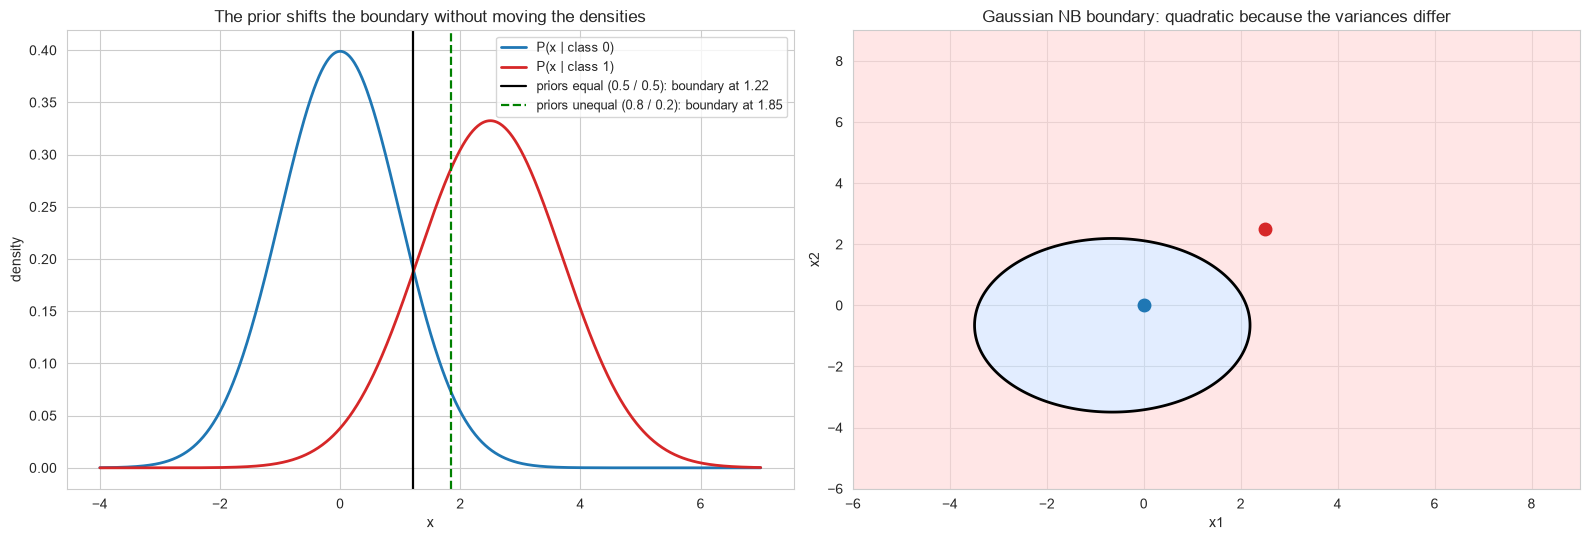

1-D boundary: priors 1.22 with equal priors, 1.85 with 0.8 / 0.2 — shifted toward the rarer class

💡 A class with a wider Gaussian claims more space around its mean. The log-odds difference is
   quadratic in x, so the boundary is a conic section; with equal variances it becomes a straight
   line. Nothing here is iterative — both boundaries are read off closed-form expressions.


In [3]:
# (a) One feature: where the weighted class-conditional densities cross
mu_a = np.array([0.0, 2.5])
sd_a = np.array([1.0, 1.2])
xs_a = np.linspace(-4.0, 7.0, 800)
log_pdf_a = -0.5 * np.log(2 * np.pi * sd_a**2) - (xs_a[:, None] - mu_a)**2 / (2 * sd_a**2)


def boundary_x(log_odds, xs, mid=1.25):
    # The crossing nearest the mid-point of the two means (a quadratic can cross twice)
    flips = np.flatnonzero(np.diff(np.sign(log_odds)))
    if len(flips) == 0:
        return np.nan
    return xs[flips[np.argmin(np.abs(xs[flips] - mid))]]


fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].plot(xs_a, np.exp(log_pdf_a[:, 0]), color="#1f77b4", lw=2, label="P(x | class 0)")
axes[0].plot(xs_a, np.exp(log_pdf_a[:, 1]), color="#d62728", lw=2, label="P(x | class 1)")
boundaries = {}
for name, priors, color, style in [("equal (0.5 / 0.5)", [0.5, 0.5], "black", "-"),
                                   ("unequal (0.8 / 0.2)", [0.8, 0.2], "green", "--")]:
    log_odds_a = (log_pdf_a[:, 1] - log_pdf_a[:, 0]) + (np.log(priors[1]) - np.log(priors[0]))
    b_pos = boundary_x(log_odds_a, xs_a)
    boundaries[name] = b_pos
    axes[0].axvline(b_pos, ls=style, color=color, lw=1.6,
                    label=f"priors {name}: boundary at {b_pos:.2f}")
axes[0].set_xlabel("x")
axes[0].set_ylabel("density")
axes[0].set_title("The prior shifts the boundary without moving the densities")
axes[0].legend(fontsize=9)

# (b) Two features, different per-class variances: the boundary is quadratic
means_b = np.array([[0.0, 0.0], [2.5, 2.5]])
sds_b = np.array([1.0, 2.2])
xx_b, yy_b = np.meshgrid(np.linspace(-6, 9, 400), np.linspace(-6, 9, 400))
pts_b = np.c_[xx_b.ravel(), yy_b.ravel()]
jll_b = np.empty((len(pts_b), 2))
for c in range(2):
    jll_b[:, c] = (-0.5 * np.log(2 * np.pi * sds_b[c]**2) * 2
                   - ((pts_b - means_b[c])**2).sum(axis=1) / (2 * sds_b[c]**2))
Z_b = (jll_b[:, 1] - jll_b[:, 0]).reshape(xx_b.shape)
axes[1].contourf(xx_b, yy_b, Z_b, levels=[Z_b.min(), 0.0, Z_b.max()],
                 colors=["#cfe2ff", "#ffd6d6"], alpha=0.6)
axes[1].contour(xx_b, yy_b, Z_b, levels=[0.0], colors="black", linewidths=2)
axes[1].plot(means_b[0, 0], means_b[0, 1], "o", color="#1f77b4", ms=9)
axes[1].plot(means_b[1, 0], means_b[1, 1], "o", color="#d62728", ms=9)
axes[1].set_title("Gaussian NB boundary: quadratic because the variances differ")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

plt.tight_layout()
plt.show()

print(f"1-D boundary: priors {boundaries['equal (0.5 / 0.5)']:.2f} with equal priors, "
      f"{boundaries['unequal (0.8 / 0.2)']:.2f} with 0.8 / 0.2 — shifted toward the rarer class")
print("\n💡 A class with a wider Gaussian claims more space around its mean. The log-odds difference is")
print("   quadratic in x, so the boundary is a conic section; with equal variances it becomes a straight")
print("   line. Nothing here is iterative — both boundaries are read off closed-form expressions.")

### Why Everything Happens in Log Space

A probability density in $d$ dimensions is a product of $d$ small numbers. Double precision bottoms out near $2.2 \times 10^{-308}$, so with enough features (or deep-enough tails) the product collapses to exactly `0.0` — and the posterior becomes `0 / 0 = NaN`. The fix is to sum log densities (a sum cannot underflow the way a product does) and to normalise by subtracting the maximum before exponentiating. The demo below shows both the failure and the fix; the scratch twin's `predict_proba` uses exactly this trick.

In [4]:
n_feat_u = 200
x_u = np.full(n_feat_u, 10.0)                     # 10 standard deviations above every mean
mu0_u, mu1_u = np.zeros(n_feat_u), np.full(n_feat_u, 5.0)

log_pdf0_u = -0.5 * np.log(2 * np.pi) - (x_u - mu0_u) ** 2 / 2.0
log_pdf1_u = -0.5 * np.log(2 * np.pi) - (x_u - mu1_u) ** 2 / 2.0
pdf0_u, pdf1_u = np.exp(log_pdf0_u), np.exp(log_pdf1_u)

p_lin0, p_lin1 = pdf0_u.prod(), pdf1_u.prod()     # products of 200 tiny densities
posterior_linear = p_lin1 / (p_lin0 + p_lin1)     # 0 / 0

jll0_u, jll1_u = log_pdf0_u.sum(), log_pdf1_u.sum()   # the same computation, in log space
log_norm_u = max(jll0_u, jll1_u)                       # logsumexp semantics: subtract the max
posterior_log = (np.exp(jll1_u - log_norm_u)
                 / (np.exp(jll0_u - log_norm_u) + np.exp(jll1_u - log_norm_u)))

print(f"Per-feature density (10 sigma from the mean):  {pdf0_u[0]:.2e}")
print(f"Smallest positive float64:                     {np.finfo(float).tiny:.2e}")
print(f"Product of 200 such densities (linear space):  {p_lin0:.2e}")
print(f"Sum of the 200 log-densities (log space):      {jll0_u:.1f}")
print(f"\nPosterior P(class 1 | x), linear space:        {posterior_linear}")
print(f"Posterior P(class 1 | x), log space:           {posterior_log:.10f}")
print("\n💡 The linear-space product underflows to exactly 0.0, and 0/0 poisons the posterior with NaN.")
print("   The log-space version subtracts the row maximum before exponentiating, so even catastrophically")
print("   small likelihoods produce clean probabilities. This is why every NB implementation lives in logs.")

Per-feature density (10 sigma from the mean):  7.69e-23
Smallest positive float64:                     2.23e-308
Product of 200 such densities (linear space):  0.00e+00
Sum of the 200 log-densities (log space):      -10183.8

Posterior P(class 1 | x), linear space:        nan
Posterior P(class 1 | x), log space:           1.0000000000

💡 The linear-space product underflows to exactly 0.0, and 0/0 poisons the posterior with NaN.
   The log-space version subtracts the row maximum before exponentiating, so even catastrophically
   small likelihoods produce clean probabilities. This is why every NB implementation lives in logs.


---

## 3. Assumptions & Requirements

Naive Bayes makes one famous assumption and a handful of practical ones. Most real failures come from the variant-feature mismatch, not from the independence assumption itself.

### Critical Assumptions

#### ✅ 1. **Conditional Independence Given the Class** (the "naive" one)
- The joint likelihood factorises into a product of per-feature terms, so features that carry the **same evidence are counted twice**
- **Test**: correlation between features within classes, and the probability-quality comparison in the demo below
- **Consequence (the surprise)**: decisions (0-1 loss) are often barely affected; the **probabilities** are what degrade — they become systematically overconfident (Domingos & Pazzani 1997)
- **Fix**: drop redundant features, or switch to logistic regression / QDA, which model or share the dependence

#### ✅ 2. **The Distribution Must Match the Variant**
- **Gaussian**: each feature roughly unimodal and symmetric *within each class*
- **Multinomial**: non-negative counts (word frequencies, event tallies)
- **Bernoulli**: binary presence/absence
- **Test**: per-feature histograms per class; the variant table in §9
- **Fix**: transform the feature (log for skewed positives), or change variant

#### ✅ 3. **Scale-Invariance — No Scaling Needed** (Gaussian)
- Standardizing changes nothing: the per-class mean/variance absorb any linear rescaling. Save the scaler
- **The trap**: the count variants are NOT scale-invariant — scaling counts breaks them (§9, mistake 2)

#### ✅ 4. **Complete Data (No Missing Values)**
- `GaussianNB` raises on NaN/inf. Impute first (`SimpleImputer`)
- **Fix**: mean/median imputation inside a pipeline — though note NB itself needs no scaler

#### ✅ 5. **Independent, Identically Distributed Rows**
- Priors and class-conditionals are frequency estimates; duplicated rows double-count evidence in the *fitting* (different from the feature-independence issue)
- **Violation fix**: group-aware or time-aware splits when rows share structure

### When Assumptions Are Violated

| Violation | Symptom | Fix |
|---|---|---|
| Correlated features | Probabilities pile at 0/1; log loss worse than logistic regression's | Drop redundant features; use LR; calibrate |
| Counts fed to GaussianNB | Weak accuracy; nonsensical negative densities | Use `MultinomialNB` |
| Standardized values fed to MultinomialNB | `ValueError: Negative values` | No scaler; or `MinMaxScaler`; or GaussianNB |
| Skewed / heavy-tailed features | One extreme value drags a class mean and variance | Log-transform; bin into categories |
| Imbalanced classes | Boundary biased toward the majority class | Set `priors` (§7) |

### Data Requirements

- **Sample size**: works from a few dozen rows per class — the most data-efficient classifier here
- **Feature scaling**: not required (Gaussian); forbidden to scale counts (Multinomial)
- **Categorical variables**: encode as non-negative integer codes for `CategoricalNB`; one-hot works everywhere else
- **Missing values**: impute before fitting
- **Class balance**: handled through the `priors` lever rather than resampling

Correlation between the two features: r = 0.770
              model  accuracy  log loss  Brier  mean max posterior
        Gaussian NB    0.9250    0.1534 0.0478              0.9414
Logistic Regression    0.9417    0.1526 0.0468              0.9302


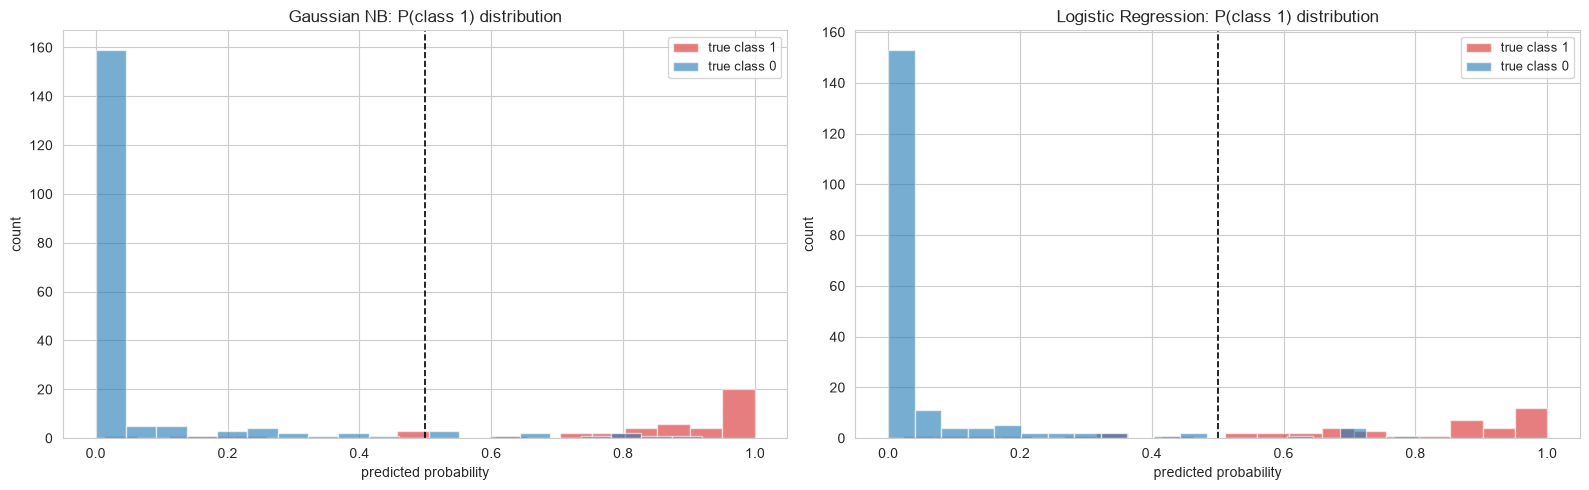


💡 Same features, nearly the same accuracy — but Gaussian NB is far more confident, because both
   features carry the same evidence and NB counts it twice. Logistic regression prices the
   redundancy into its coefficients. Independence violations hurt the *probabilities* long before
   they hurt the *decisions* — the Domingos & Pazzani result, reproduced in four lines.


In [5]:
# The independence lesson: two features carrying the SAME evidence
rng_c = np.random.default_rng(42)
n_c = 800
latent_c = rng_c.normal(0.0, 1.0, n_c)
y_c = (latent_c > 0.8).astype(int)                       # about 21% positives
X_c = np.c_[latent_c + rng_c.normal(0.0, 0.5, n_c),
            latent_c + rng_c.normal(0.0, 0.5, n_c)]      # x2 is a noisy copy of x1
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.3,
                                              stratify=y_c, random_state=42)

print(f"Correlation between the two features: r = {np.corrcoef(Xc_tr, rowvar=False)[0, 1]:.3f}")

nb_c = GaussianNB().fit(Xc_tr, yc_tr)
lr_c = LogisticRegression().fit(Xc_tr, yc_tr)

rows_c = []
for name, model in [("Gaussian NB", nb_c), ("Logistic Regression", lr_c)]:
    proba_c = model.predict_proba(Xc_te)[:, 1]
    rows_c.append({
        "model": name,
        "accuracy": accuracy_score(yc_te, model.predict(Xc_te)),
        "log loss": log_loss(yc_te, proba_c),
        "Brier": brier_score_loss(yc_te, proba_c),
        "mean max posterior": model.predict_proba(Xc_te).max(axis=1).mean(),
    })
c_df = pd.DataFrame(rows_c)
print(c_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (name, model) in zip(axes, [("Gaussian NB", nb_c), ("Logistic Regression", lr_c)]):
    proba_c = model.predict_proba(Xc_te)[:, 1]
    ax.hist(proba_c[yc_te == 1], bins=20, alpha=0.6, color="#d62728", label="true class 1")
    ax.hist(proba_c[yc_te == 0], bins=20, alpha=0.6, color="#1f77b4", label="true class 0")
    ax.axvline(0.5, color="black", ls="--", lw=1.2)
    ax.set_title(f"{name}: P(class 1) distribution")
    ax.set_xlabel("predicted probability")
    ax.set_ylabel("count")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n💡 Same features, nearly the same accuracy — but Gaussian NB is far more confident, because both")
print("   features carry the same evidence and NB counts it twice. Logistic regression prices the")
print("   redundancy into its coefficients. Independence violations hurt the *probabilities* long before")
print("   they hurt the *decisions* — the Domingos & Pazzani result, reproduced in four lines.")

---

## 4. When to Use This Algorithm

### ✅ Use Naive Bayes When:

1. **Speed is the constraint**
   - One-pass training, one-pass prediction, tiny model. Real-time and streaming-friendly
2. **The dataset is small**
   - A few dozen rows per class fit a usable model; nothing else in this repo is that data-efficient
3. **Text or other high-dimensional count data**
   - Thousands of word-count features are exactly MultinomialNB's regime; it was the spam-era workhorse
4. **You want a fast, honest baseline**
   - Its accuracy is the floor every heavier model must beat — and on text it is often genuinely competitive
5. **Probabilities are directionally useful**
   - Native `predict_proba`, unlike the SVM; just check calibration first (§3, §10)
6. **The model must be interpretable at the word level**
   - `feature_log_prob_` differences explain every prediction word by word

### ❌ Avoid Naive Bayes When:

1. **Calibrated probabilities are the product and features correlate**
   - NB posteriors are systematically overconfident under dependence; logistic regression is the safer tool
2. **Feature interactions carry the signal**
   - The likelihood is a product of one-feature terms; "cheap AND urgent" cannot exceed the product
3. **Heavy-tailed continuous features with no transformation budget**
   - One extreme value drags a class mean and variance; a tree or a robust model needs no such care
4. **You need the last percent of accuracy**
   - Boosted trees and SVMs usually win on clean tabular data — NB's role is the baseline, not the champion
5. **The variant-feature match is impossible**
   - Continuous text embeddings, or mixed types needing different variants — a single NB variant cannot serve both

### Classification Only

| Task | Variant | Covered in |
|---|---|---|
| Classification (continuous features) | `GaussianNB` | §5 (scratch twin), §6 to §11 |
| Classification (count features / text) | `MultinomialNB`, `ComplementNB` | §6, §7, §10 Example 2 |
| Classification (binary features) | `BernoulliNB` | §6, §7 |
| Classification (categorical codes) | `CategoricalNB` | §8 reference |

There is no Naive Bayes regressor in scikit-learn.

### Naive Bayes vs Other Algorithms (short version; full comparison in §11)

- **vs Logistic Regression (02)**: same linear regime, opposite philosophies — NB is generative and one-pass; LR is discriminative and prices correlations correctly
- **vs SVM (05)**: NB trains in one pass and ships native probabilities; the SVM earns its margin geometry at a much higher training cost
- **vs KNN (07)**: NB stores $O(C \cdot d)$ numbers; KNN stores the whole training set and pays for it at predict time
- **vs Random Forest (04)**: forests need no distributional assumptions and handle interactions; NB assumes independence and unimodality — and wins when its assumptions hold

              model  fit (s)  predict 2500 rows (s)  test accuracy
        Gaussian NB   0.0022                 0.0005         0.8052
Logistic Regression   0.0070                 0.0007         0.8092
         Linear SVC   0.0114                 0.0009         0.8100
          KNN (k=7)   0.0112                 0.0798         0.9444


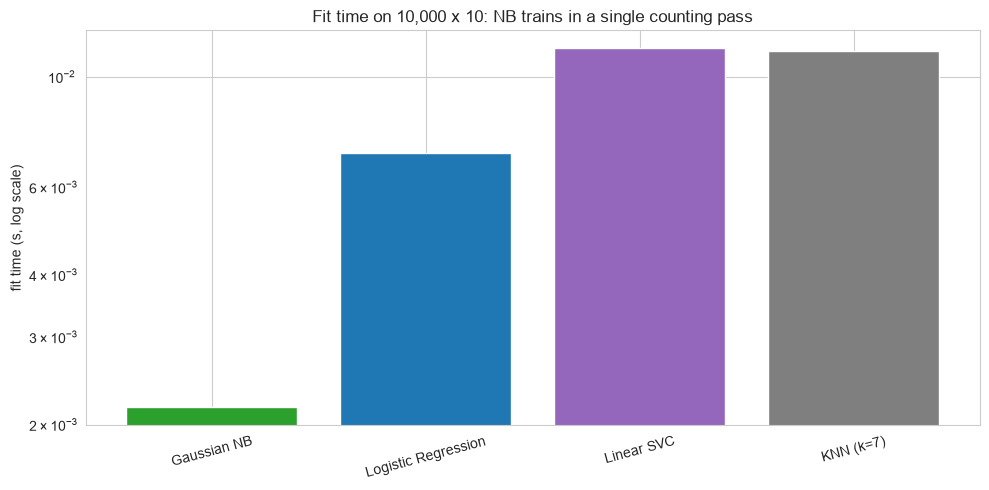


💡 Gaussian NB is a counting pass — no iterations, no convergence. Use it to set the baseline
   every other model must beat, and as the first model to fit on any new tabular problem.


In [6]:
# Speed is the claim — here is the receipt. Same data, same protocol for every model.
X_speed, y_speed = make_classification(n_samples=10000, n_features=10, n_informative=6,
                                       random_state=42)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_speed, y_speed, test_size=0.25,
                                              stratify=y_speed, random_state=42)

speed_models = {
    "Gaussian NB": GaussianNB(),
    "Logistic Regression": Pipeline([("sc", StandardScaler()),
                                     ("clf", LogisticRegression(max_iter=2000))]),
    "Linear SVC": Pipeline([("sc", StandardScaler()),
                            ("clf", LinearSVC(max_iter=5000))]),
    "KNN (k=7)": Pipeline([("sc", StandardScaler()),
                           ("clf", KNeighborsClassifier(n_neighbors=7))]),
}

rows_speed = []
for name_s, model_s in speed_models.items():
    t0 = time.perf_counter()
    model_s.fit(Xs_tr, ys_tr)
    t_fit_s = time.perf_counter() - t0
    t0 = time.perf_counter()
    model_s.predict(Xs_te)
    t_pred_s = time.perf_counter() - t0
    rows_speed.append({"model": name_s, "fit (s)": t_fit_s,
                       "predict 2500 rows (s)": t_pred_s,
                       "test accuracy": model_s.score(Xs_te, ys_te)})
speed_df = pd.DataFrame(rows_speed)
print(speed_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(speed_df["model"], speed_df["fit (s)"], color=["#2ca02c", "#1f77b4", "#9467bd", "#7f7f7f"])
ax.set_yscale("log")
ax.set_ylabel("fit time (s, log scale)")
ax.set_title("Fit time on 10,000 x 10: NB trains in a single counting pass")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\n💡 Gaussian NB is a counting pass — no iterations, no convergence. Use it to set the baseline")
print("   every other model must beat, and as the first model to fit on any new tabular problem.")

---

## 5. Implementation from Scratch (NumPy)

### Why Implement Naive Bayes from Scratch?

- The whole algorithm is a handful of NumPy lines — the shortest twin in this repo
- It makes the generative view concrete: after `fit`, the model *is* just three arrays (priors, means, variances)
- It shows where the numerics live: log space, the max-subtraction normalisation, the variance floor

The from-scratch twin lives in `src/models/naive_bayes_models.py` as **`GaussianNaiveBayesScratch`**. Fit is a single closed-form pass (priors via `bincount`, per-class means and population variances); predict evaluates Gaussian log-densities in log space and normalises with logsumexp semantics. It mirrors sklearn's attribute names (`classes_`, `class_prior_`, `theta_`, `var_`, `epsilon_`).

What is deliberately simplified (documented in the module):
- predict/predict_proba work from one matrix of log posteriors, while sklearn accumulates class-by-class via a private `_joint_log_likelihood` — same numbers, simpler plumbing
- No `partial_fit` / incremental updates; fit is one closed form over the whole batch
- No `sample_weight` support
- Gaussian variant only — Multinomial/Bernoulli/Categorical target count/binary/categorical features and are out of scope

In [7]:
# Import our from-scratch implementation
import sys
sys.path.append('../src')

from models.naive_bayes_models import GaussianNaiveBayesScratch

print("✅ Imported custom Naive Bayes implementation!")
print("\nAvailable class:")
print("  • GaussianNaiveBayesScratch: Gaussian NB, closed-form fit, log-space predict")
print("\nAPI (mirrors scikit-learn's GaussianNB names):")
print("  • .fit(X, y) estimates priors, per-class means and variances in one pass")
print("  • .predict(X), .predict_proba(X), .score(X, y)")
print("  • classes_, class_prior_, theta_, var_, epsilon_")

✅ Imported custom Naive Bayes implementation!

Available class:
  • GaussianNaiveBayesScratch: Gaussian NB, closed-form fit, log-space predict

API (mirrors scikit-learn's GaussianNB names):
  • .fit(X, y) estimates priors, per-class means and variances in one pass
  • .predict(X), .predict_proba(X), .score(X, y)
  • classes_, class_prior_, theta_, var_, epsilon_


### Classification Example (From Scratch)

The moons dataset again — chosen deliberately: the two crescents' coordinates are **correlated**, which is exactly where the independence assumption shows its effect. Note one contrast with notebook 05: **no scaler**. Gaussian NB is scale-invariant because it estimates per-feature means and variances, so standardizing would change nothing.

In [8]:
X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_moon, y_moon, test_size=0.3,
                                              stratify=y_moon, random_state=42)

print("=" * 60)
print("GAUSSIAN NAIVE BAYES (FROM SCRATCH)")
print("=" * 60)
print("\n📊 Dataset:")
print(f"  Training samples: {len(Xm_tr)}")
print(f"  Test samples:     {len(Xm_te)}")
print(f"  Features:         {Xm_tr.shape[1]}")

nb_scr = GaussianNaiveBayesScratch(var_smoothing=1e-9)
t0 = time.perf_counter()
nb_scr.fit(Xm_tr, ym_tr)
t_nb = time.perf_counter() - t0

print("\n🌀 Fitted attributes:")
print(f"  classes_     = {nb_scr.classes_}")
print(f"  class_prior_ = {nb_scr.class_prior_}")
print("  theta_ (per-class per-feature means):")
print(pd.DataFrame(nb_scr.theta_, index=[f"class {c}" for c in nb_scr.classes_],
                   columns=["x1", "x2"]).round(3).to_string())
print("  var_   (per-class per-feature variances, smoothed):")
print(pd.DataFrame(nb_scr.var_, index=[f"class {c}" for c in nb_scr.classes_],
                   columns=["x1", "x2"]).round(3).to_string())
print(f"  epsilon_     = {nb_scr.epsilon_:.3e}   (= var_smoothing × max feature variance)")

print("\n🌀 Results:")
print(f"  train accuracy: {nb_scr.score(Xm_tr, ym_tr):.4f}")
print(f"  test accuracy:  {nb_scr.score(Xm_te, ym_te):.4f}")
print(f"  fit time:       {t_nb:.4f} s   (single closed-form pass — no iterations)")
print("\n💡 One pass, no iterations, no learning rate. Fit is just counting and averaging, and the")
print("   whole model is the three arrays printed above.")

GAUSSIAN NAIVE BAYES (FROM SCRATCH)

📊 Dataset:
  Training samples: 210
  Test samples:     90
  Features:         2

🌀 Fitted attributes:
  classes_     = [0 1]
  class_prior_ = [0.5 0.5]
  theta_ (per-class per-feature means):
            x1     x2
class 0 -0.055  0.677
class 1  1.037 -0.078
  var_   (per-class per-feature variances, smoothed):
            x1     x2
class 0  0.539  0.125
class 1  0.555  0.128
  epsilon_     = 8.454e-10   (= var_smoothing × max feature variance)

🌀 Results:
  train accuracy: 0.8667
  test accuracy:  0.8333
  fit time:       0.0005 s   (single closed-form pass — no iterations)

💡 One pass, no iterations, no learning rate. Fit is just counting and averaging, and the
   whole model is the three arrays printed above.


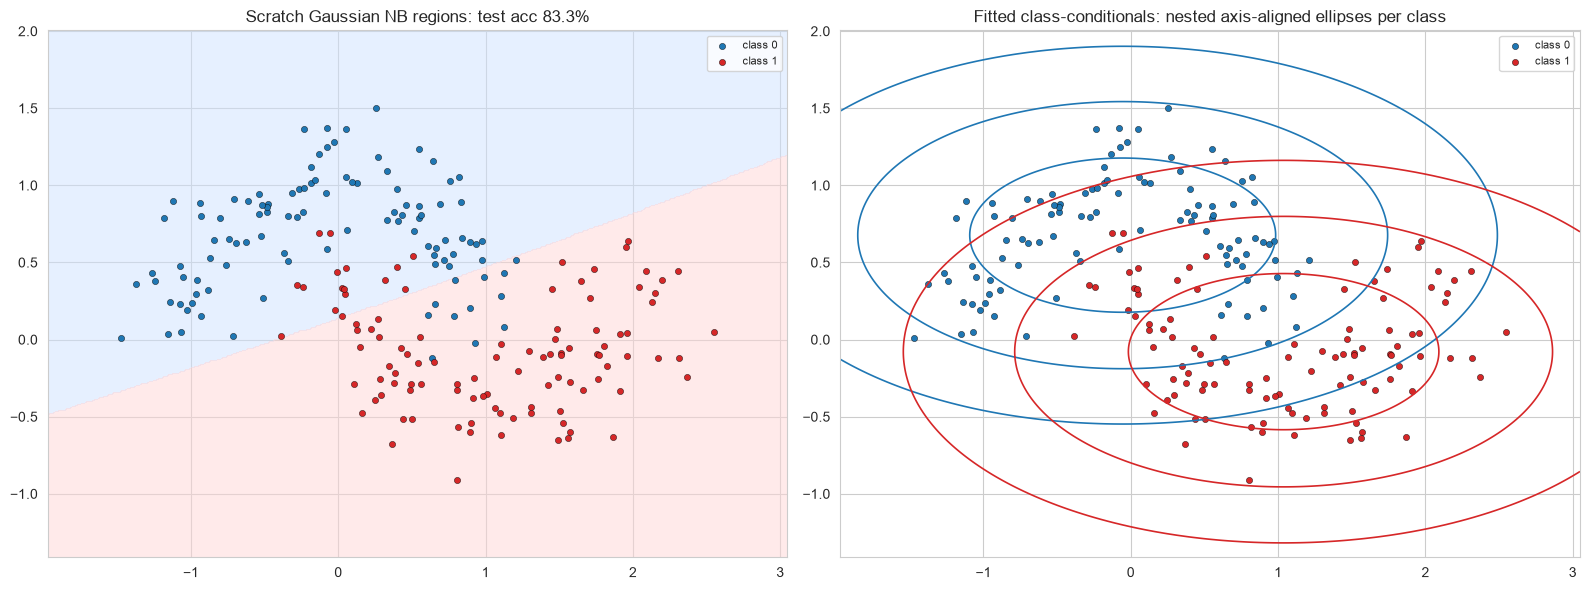

💡 Each ring is one class's P(x) landscape: widest along the features it varies most in, and
   always aligned with the axes — that is the independence assumption drawn. The moons crescents
   are correlated, so the tilted contour the data 'wants' cannot be represented, and the
   decision boundary bends where the axis-aligned shapes disagree.


In [9]:
def plot_nb_regions(ax, model, X, y, title):
    # Predicted-label regions of a 2-D classifier fitted on raw coordinates (binary labels).
    # Works for any model exposing predict(): the scratch twin and sklearn's GaussianNB alike.
    pad = 0.5
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 300),
        np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 300),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5], colors=["#cfe2ff", "#ffd6d6"], alpha=0.5)
    for label, color in zip(np.unique(y), ["#1f77b4", "#d62728"]):
        ax.scatter(X[y == label, 0], X[y == label, 1], c=color, s=20,
                   edgecolors="k", linewidths=0.3, label=f"class {label}")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_nb_regions(axes[0], nb_scr, Xm_tr, ym_tr,
                f"Scratch Gaussian NB regions: test acc {nb_scr.score(Xm_te, ym_te):.1%}")

# The class-conditionals the model actually fits: products of per-feature Gaussians.
xx_e, yy_e = np.meshgrid(np.linspace(Xm_tr[:, 0].min() - 0.5, Xm_tr[:, 0].max() + 0.5, 300),
                         np.linspace(Xm_tr[:, 1].min() - 0.5, Xm_tr[:, 1].max() + 0.5, 300))
grid_e = np.c_[xx_e.ravel(), yy_e.ravel()]
for c, (cls, color) in enumerate(zip(nb_scr.classes_, ["#1f77b4", "#d62728"])):
    log_pdf_e = (-0.5 * np.log(2 * np.pi * nb_scr.var_[c])
                 - (grid_e - nb_scr.theta_[c]) ** 2 / (2 * nb_scr.var_[c])).sum(axis=1)
    pdf_e = np.exp(log_pdf_e).reshape(xx_e.shape)
    axes[1].contour(xx_e, yy_e, pdf_e, levels=pdf_e.max() * np.exp([-6.0, -3.0, -1.0]),
                    colors=color, linewidths=1.2)
for label, color in zip(np.unique(ym_tr), ["#1f77b4", "#d62728"]):
    axes[1].scatter(Xm_tr[ym_tr == label, 0], Xm_tr[ym_tr == label, 1], c=color, s=20,
                    edgecolors="k", linewidths=0.3, label=f"class {label}")
axes[1].set_title("Fitted class-conditionals: nested axis-aligned ellipses per class")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("💡 Each ring is one class's P(x) landscape: widest along the features it varies most in, and")
print("   always aligned with the axes — that is the independence assumption drawn. The moons crescents")
print("   are correlated, so the tilted contour the data 'wants' cannot be represented, and the")
print("   decision boundary bends where the axis-aligned shapes disagree.")

### Reconstructing the Posterior by Hand

The prediction rule is literally

$$\text{jll}_c(x) = \log \pi_c + \sum_{j=1}^{d}\left[-\tfrac{1}{2}\log(2\pi\sigma_{cj}^2) - \frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right], \qquad P(y = c \mid x) = \frac{e^{\text{jll}_c(x)}}{\sum_{c'} e^{\text{jll}_{c'}(x)}}$$

computed with the max-subtraction trick: subtract $\max_{c'} \text{jll}_{c'}(x)$ from every term before exponentiating. Rebuilding it from the stored `theta_`, `var_` and `class_prior_` shows that **nothing else from training is needed at prediction time** — there is no hidden state.

In [10]:
X_t = Xm_te
jll_hand = np.empty((len(X_t), len(nb_scr.classes_)))
for c, cls in enumerate(nb_scr.classes_):
    log_pdf_h = (-0.5 * np.log(2 * np.pi * nb_scr.var_[c])
                 - (X_t - nb_scr.theta_[c]) ** 2 / (2 * nb_scr.var_[c]))
    jll_hand[:, c] = np.log(nb_scr.class_prior_[c]) + log_pdf_h.sum(axis=1)

log_norm_h = jll_hand.max(axis=1, keepdims=True)
proba_hand = np.exp(jll_hand - log_norm_h)
proba_hand /= proba_hand.sum(axis=1, keepdims=True)

print(f"Max |hand-built posterior - predict_proba|: {np.max(np.abs(proba_hand - nb_scr.predict_proba(X_t))):.2e}")
pred_from_hand = nb_scr.classes_[jll_hand.argmax(axis=1)]
print(f"Hand-built argmax matches predict():        {np.array_equal(pred_from_hand, nb_scr.predict(X_t))}")

row_h = 0
x_row = X_t[row_h]
print("\nOne test row, step by step:")
print(f"  x = {np.round(x_row, 3)}")
for c, cls in enumerate(nb_scr.classes_):
    per_feature_h = (-0.5 * np.log(2 * np.pi * nb_scr.var_[c])
                     - (x_row - nb_scr.theta_[c]) ** 2 / (2 * nb_scr.var_[c]))
    print(f"  class {cls}: log prior {np.log(nb_scr.class_prior_[c]):+.3f} | "
          f"per-feature log-densities {np.round(per_feature_h, 3)} | jll {jll_hand[row_h, c]:+.3f}")
print(f"  posterior: {np.round(proba_hand[row_h], 4)}  -> predicted {pred_from_hand[row_h]}")
print("\n💡 Prediction needs nothing but the fitted theta_, var_ and class_prior_. No support vectors,")
print("   no stored data, no solver state — the smallest model object in this repo.")

Max |hand-built posterior - predict_proba|: 0.00e+00
Hand-built argmax matches predict():        True

One test row, step by step:
  x = [ 1.59  -0.874]
  class 0: log prior -0.693 | per-feature log-densities [-3.122 -9.504] | jll -13.319
  class 1: log prior -0.693 | per-feature log-densities [-0.9   -2.362] | jll -3.956
  posterior: [1.000e-04 9.999e-01]  -> predicted 1

💡 Prediction needs nothing but the fitted theta_, var_ and class_prior_. No support vectors,
   no stored data, no solver state — the smallest model object in this repo.


### The Smoothing Lesson (var_smoothing)

A feature with (near-)zero variance in one class makes that class's density spike — one $P(x_j \mid y)$ explodes and dominates every decision. The fix is a **variance floor**: every variance is widened to at least $\sigma^2 + \epsilon$, with $\epsilon = \text{var\_smoothing} \times \max_j \mathrm{Var}(x_j)$ — a share of the largest feature variance, so the floor scales with the data. The twin stores the smoothed values in `var_` (as sklearn does) and raises if `var_smoothing <= 0`.

 var_smoothing  test accuracy  mean max posterior (train)  min smoothed var_
        0.0000         0.8333                      0.9153             0.1250
        0.0000         0.8333                      0.9153             0.1250
        0.0000         0.8333                      0.9153             0.1250
        0.0010         0.8333                      0.9149             0.1258
        0.1000         0.8222                      0.8758             0.2095


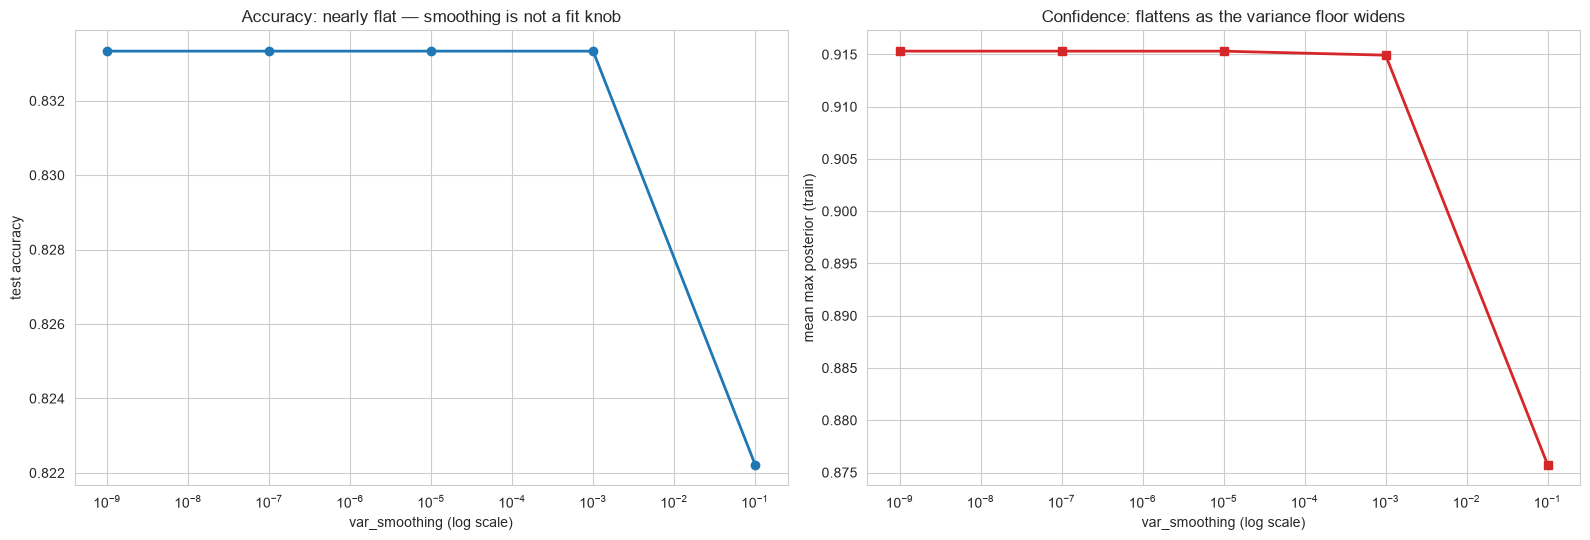

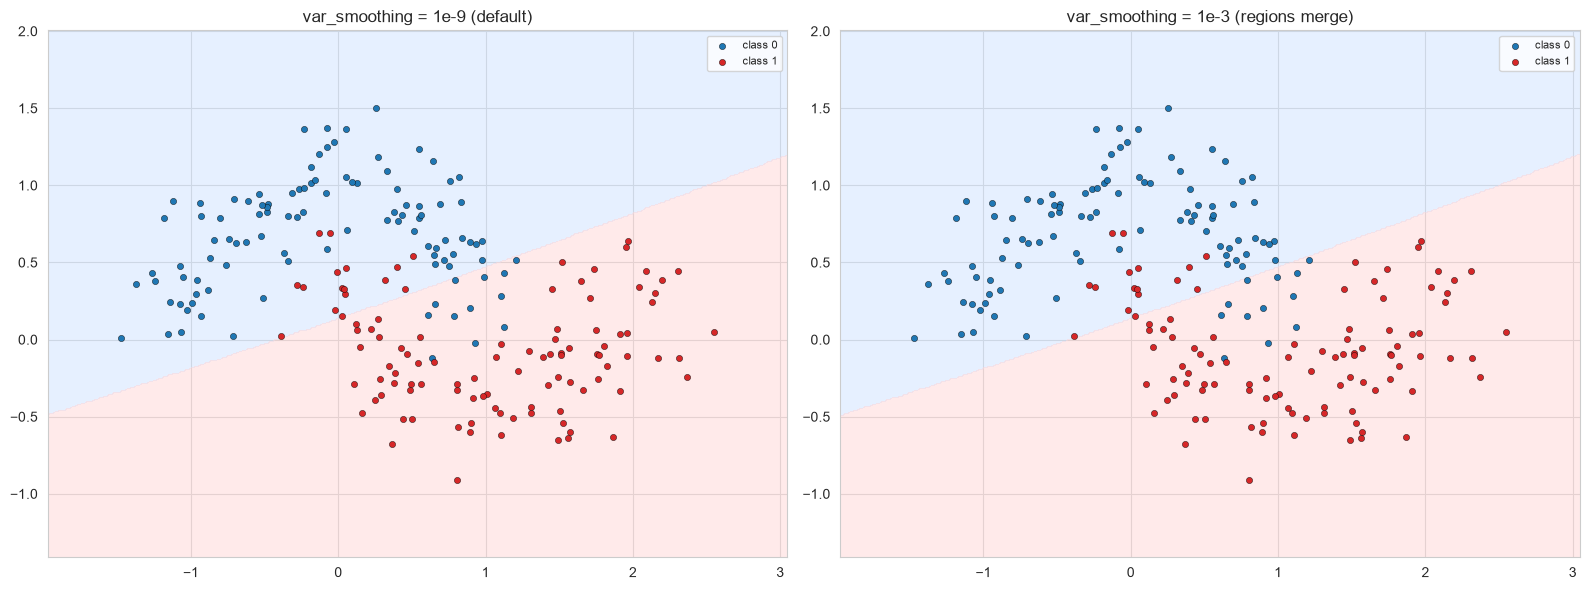


💡 The variance floor is a numerical-stability knob, not a fit knob: accuracy barely moves across
   eleven orders of magnitude, while the confidence — and the regions — flatten visibly at 1e-3.


In [11]:
smoothings = [1e-9, 1e-7, 1e-5, 1e-3, 1e-1]
rows_sm = []
for s_val in smoothings:
    m_s = GaussianNaiveBayesScratch(var_smoothing=s_val).fit(Xm_tr, ym_tr)
    rows_sm.append({
        "var_smoothing": s_val,
        "test accuracy": m_s.score(Xm_te, ym_te),
        "mean max posterior (train)": m_s.predict_proba(Xm_tr).max(axis=1).mean(),
        "min smoothed var_": m_s.var_.min(),
    })
sm_df = pd.DataFrame(rows_sm)
print(sm_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].semilogx(sm_df["var_smoothing"], sm_df["test accuracy"], "o-", color="#1f77b4", lw=2)
axes[0].set_xlabel("var_smoothing (log scale)")
axes[0].set_ylabel("test accuracy")
axes[0].set_title("Accuracy: nearly flat — smoothing is not a fit knob")
axes[1].semilogx(sm_df["var_smoothing"], sm_df["mean max posterior (train)"], "s-",
                 color="#d62728", lw=2)
axes[1].set_xlabel("var_smoothing (log scale)")
axes[1].set_ylabel("mean max posterior (train)")
axes[1].set_title("Confidence: flattens as the variance floor widens")
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
plot_nb_regions(axes2[0], GaussianNaiveBayesScratch(var_smoothing=1e-9).fit(Xm_tr, ym_tr),
                Xm_tr, ym_tr, "var_smoothing = 1e-9 (default)")
plot_nb_regions(axes2[1], GaussianNaiveBayesScratch(var_smoothing=1e-3).fit(Xm_tr, ym_tr),
                Xm_tr, ym_tr, "var_smoothing = 1e-3 (regions merge)")
plt.tight_layout()
plt.show()

print("\n💡 The variance floor is a numerical-stability knob, not a fit knob: accuracy barely moves across")
print("   eleven orders of magnitude, while the confidence — and the regions — flatten visibly at 1e-3.")

### How the Scratch Version Works (a guided tour)

Read `src/models/naive_bayes_models.py` alongside these facts:

**1. Arbitrary labels are mapped, never assumed.**
`classes_ = np.unique(y)` and `y_idx = np.searchsorted(classes_, y)`. Any labels — strings, `{10, 20}`, a single class — work, because nothing downstream assumes integers `0/1`. Ties in the log posteriors break toward the lower class, as in sklearn.

**2. Priors are one `bincount` away.**
`class_prior_ = bincount(y_idx, minlength=C) / len(y)`. No smoothing of the prior itself; the variance floor is where smoothing lives.

**3. Per-class statistics are closed form.**
For each class: `theta_[c] = X_c.mean(axis=0)` and `raw_var[c] = X_c.var(axis=0)` — **population variance (`ddof=0`)**, which is exactly sklearn's convention and why the two engines agree to floating point.

**4. The epsilon formula is relative to the data's scale.**
`epsilon_ = var_smoothing * X.var(axis=0).max()`. A relative share (not an absolute constant) means the floor adapts to feature scales and is never zero unless the data itself is constant.

**5. `var_` stores the smoothed value.**
`var_ = raw_var + epsilon_`, so predict evaluates exactly what fit stored — no re-addition at predict time, no drift between what you inspect and what you compute with.

**6. The log density is written out, one class per loop row.**
`log N(x_j | theta, var) = -0.5*log(2*pi*var) - (x_j - theta)^2 / (2*var)`, summed over features, plus the log prior. The loop over classes keeps the read-friendly formula; C is small so the loop cost is trivial.

**7. Normalisation uses logsumexp semantics.**
`predict_proba` subtracts the row maximum of the jll matrix before exponentiating (§2's demo), so no likelihood magnitude can overflow or underflow the posterior.

**8. What the twin deliberately leaves out.**
No `partial_fit`, no `sample_weight`, no `priors` override, no Multinomial/Bernoulli/Categorical variants. One validation rule: `var_smoothing` must be `> 0` — checked with `not self.var_smoothing > 0` because a NaN would silently pass a `<= 0` test. Everything is deterministic: same data, same numbers, every time.

---

## 6. Implementation with Scikit-learn

scikit-learn's `naive_bayes` module is a family: `GaussianNB` for continuous features, `MultinomialNB` and `BernoulliNB` for text-style counts and binary flags, `ComplementNB` for imbalanced text, `CategoricalNB` for integer-coded categories. A few API facts worth pinning before the first fit:

- **Probabilities are native** — `predict_proba` needs no `probability=True` dance like SVC. But native ≠ calibrated (§3)
- **Multiclass is native** — one prior, one mean vector and one variance vector per class; no one-vs-rest wrappers
- **`partial_fit` exists** on every variant — the only classifier family here with first-class streaming support
- **No scaler** for `GaussianNB` — and a scaler actively breaks `MultinomialNB` (negative counts)
- The single continuous-feature knob is `var_smoothing`; the priors override is `priors`

In [12]:
nb_sk = GaussianNB().fit(Xm_tr, ym_tr)
y_pred_sk = nb_sk.predict(Xm_te)
proba_sk = nb_sk.predict_proba(Xm_te)[:, 1]

print("=" * 60)
print("GAUSSIAN NAIVE BAYES (SCIKIT-LEARN)")
print("=" * 60)
print(f"  Accuracy:  {accuracy_score(ym_te, y_pred_sk):.4f}")
print(f"  Precision: {precision_score(ym_te, y_pred_sk):.4f}")
print(f"  Recall:    {recall_score(ym_te, y_pred_sk):.4f}")
print(f"  F1-Score:  {f1_score(ym_te, y_pred_sk):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(ym_te, proba_sk):.4f}   (native probabilities — no calibration step)")

print("\n📋 Classification Report:")
print(classification_report(ym_te, y_pred_sk, target_names=["Class 0", "Class 1"]))

print("🔍 Fitted attributes:")
print(f"  classes_      = {nb_sk.classes_}")
print(f"  class_count_  = {nb_sk.class_count_}   (rows seen per class)")
print(f"  class_prior_  = {nb_sk.class_prior_}")
print(f"  theta_        = shape {nb_sk.theta_.shape}   (per-class per-feature means)")
print(f"  var_          = shape {nb_sk.var_.shape}   (per-class per-feature variances, smoothed)")
print(f"  epsilon_      = {nb_sk.epsilon_:.3e}   (the absolute variance floor that was added)")

GAUSSIAN NAIVE BAYES (SCIKIT-LEARN)
  Accuracy:  0.8333
  Precision: 0.7885
  Recall:    0.9111
  F1-Score:  0.8454
  ROC-AUC:   0.9417   (native probabilities — no calibration step)

📋 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.89      0.76      0.82        45
     Class 1       0.79      0.91      0.85        45

    accuracy                           0.83        90
   macro avg       0.84      0.83      0.83        90
weighted avg       0.84      0.83      0.83        90

🔍 Fitted attributes:
  classes_      = [0 1]
  class_count_  = [105. 105.]   (rows seen per class)
  class_prior_  = [0.5 0.5]
  theta_        = shape (2, 2)   (per-class per-feature means)
  var_          = shape (2, 2)   (per-class per-feature variances, smoothed)
  epsilon_      = 8.454e-10   (the absolute variance floor that was added)


MULTICLASS: IRIS (3 CLASSES, 4 FEATURES)
  Accuracy: 0.9111

📋 Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

🔍 Priors (learned from the label frequencies):
  setosa      : prior 0.333  (35 training rows)
  versicolor  : prior 0.333  (35 training rows)
  virginica   : prior 0.333  (35 training rows)


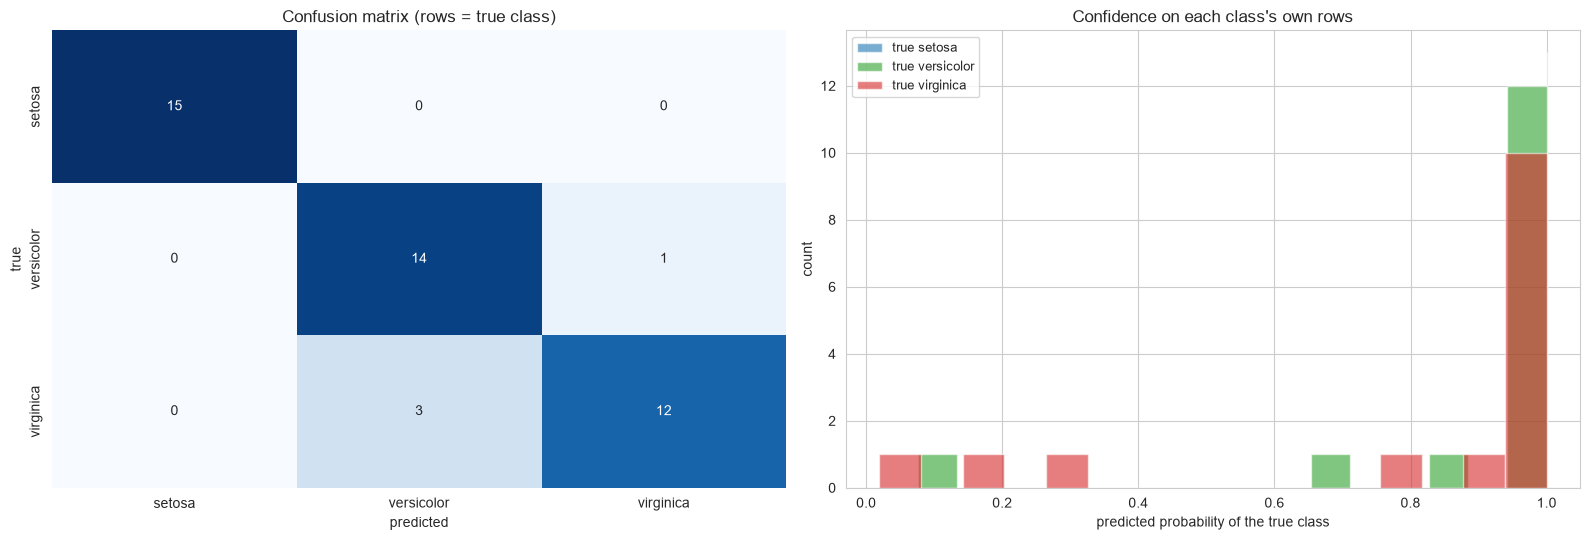

💡 Multiclass needs no wrapper: one prior, one mean vector and one variance vector per class,
   then the same argmax over log posteriors. The setosa/virginica separation is exact; the
   versicolor/virginica overlap is where the probability histogram shows the uncertainty.


In [13]:
iris = load_iris()
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(iris.data, iris.target, test_size=0.3,
                                              stratify=iris.target, random_state=42)
nb_iris = GaussianNB().fit(Xi_tr, yi_tr)
pred_i = nb_iris.predict(Xi_te)

print("=" * 60)
print("MULTICLASS: IRIS (3 CLASSES, 4 FEATURES)")
print("=" * 60)
print(f"  Accuracy: {accuracy_score(yi_te, pred_i):.4f}")
print("\n📋 Classification Report:")
print(classification_report(yi_te, pred_i, target_names=list(iris.target_names)))
print("🔍 Priors (learned from the label frequencies):")
for cls_i, prior_i, count_i in zip(nb_iris.classes_, nb_iris.class_prior_, nb_iris.class_count_):
    print(f"  {iris.target_names[cls_i]:<12s}: prior {prior_i:.3f}  ({int(count_i)} training rows)")

cm_i = confusion_matrix(yi_te, pred_i)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.heatmap(cm_i, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=iris.target_names, yticklabels=iris.target_names)
axes[0].set_title("Confusion matrix (rows = true class)")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("true")

proba_i = nb_iris.predict_proba(Xi_te)
for cls_i, color_i in zip(nb_iris.classes_, ["#1f77b4", "#2ca02c", "#d62728"]):
    axes[1].hist(proba_i[yi_te == cls_i, cls_i], bins=16, alpha=0.6, color=color_i,
                 label=f"true {iris.target_names[cls_i]}")
axes[1].set_xlabel("predicted probability of the true class")
axes[1].set_ylabel("count")
axes[1].set_title("Confidence on each class's own rows")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print("💡 Multiclass needs no wrapper: one prior, one mean vector and one variance vector per class,")
print("   then the same argmax over log posteriors. The setosa/virginica separation is exact; the")
print("   versicolor/virginica overlap is where the probability histogram shows the uncertainty.")

### Dual Engine: Scratch vs Scikit-learn on the Same Data

This is where Naive Bayes differs from the SVM notebook in the most satisfying way. SVM is an iterative solver: two engines stop at slightly different points, so their alphas and bias differ slightly even when predictions agree. NB has **no solver** — both engines evaluate the same closed-form expressions on the same statistics, so the agreement should be **exact to floating point**. The behavioral tests pin this at better than 1e-9; in practice you will see ~1e-16.

In [14]:
t0 = time.perf_counter()
nb_scr_de = GaussianNaiveBayesScratch(var_smoothing=1e-9).fit(Xm_tr, ym_tr)
t_scr_de = time.perf_counter() - t0
t0 = time.perf_counter()
nb_sk_de = GaussianNB(var_smoothing=1e-9).fit(Xm_tr, ym_tr)
t_sk_de = time.perf_counter() - t0

pred_scr_de = nb_scr_de.predict(Xm_te)
pred_sk_de = nb_sk_de.predict(Xm_te)

print("=" * 60)
print("DUAL ENGINE: SCRATCH vs SCIKIT-LEARN (same data, same var_smoothing)")
print("=" * 60)
print(f"| {'Metric':<32s} | {'Scratch':>12s} | {'Scikit-learn':>12s} |")
print(f"|{'-' * 34}|{'-' * 14}|{'-' * 14}|")
print(f"| {'test accuracy':<32s} | {nb_scr_de.score(Xm_te, ym_te):12.4f} | {nb_sk_de.score(Xm_te, ym_te):12.4f} |")
print(f"| {'fit time (s)':<32s} | {t_scr_de:12.4f} | {t_sk_de:12.4f} |")
print(f"\nPrediction agreement on test rows:      {np.mean(pred_scr_de == pred_sk_de):.1%}")
print(f"Max |posterior difference|:             {np.max(np.abs(nb_scr_de.predict_proba(Xm_te) - nb_sk_de.predict_proba(Xm_te))):.2e}")
print(f"Max |theta_ difference|:                {np.max(np.abs(nb_scr_de.theta_ - nb_sk_de.theta_)):.2e}")
print(f"Max |var_ difference|:                  {np.max(np.abs(nb_scr_de.var_ - nb_sk_de.var_)):.2e}")
print("\n💡 Both engines compute the identical closed form, so agreement is exact to floating point —")
print("   the same numbers, not approximately the same numbers. That is what")
print("   tests/models/test_naive_bayes_models.py pins down (< 1e-9 on several geometries).")

DUAL ENGINE: SCRATCH vs SCIKIT-LEARN (same data, same var_smoothing)
| Metric                           |      Scratch | Scikit-learn |
|----------------------------------|--------------|--------------|
| test accuracy                    |       0.8333 |       0.8333 |
| fit time (s)                     |       0.0007 |       0.0026 |

Prediction agreement on test rows:      100.0%
Max |posterior difference|:             2.22e-16
Max |theta_ difference|:                0.00e+00
Max |var_ difference|:                  0.00e+00

💡 Both engines compute the identical closed form, so agreement is exact to floating point —
   the same numbers, not approximately the same numbers. That is what
   tests/models/test_naive_bayes_models.py pins down (< 1e-9 on several geometries).


### Generative View: Sampling from the Fitted Model

The twin and `GaussianNB` model $P(x \mid y)$ **explicitly** — which means the fitted object can *generate* new data: draw from each class's Gaussians. A discriminative model (logistic regression, SVM) models only $P(y \mid x)$ and cannot do this. It is also the clearest way to see what the model believes the data looks like — axis-aligned Gaussians, correlations and all.

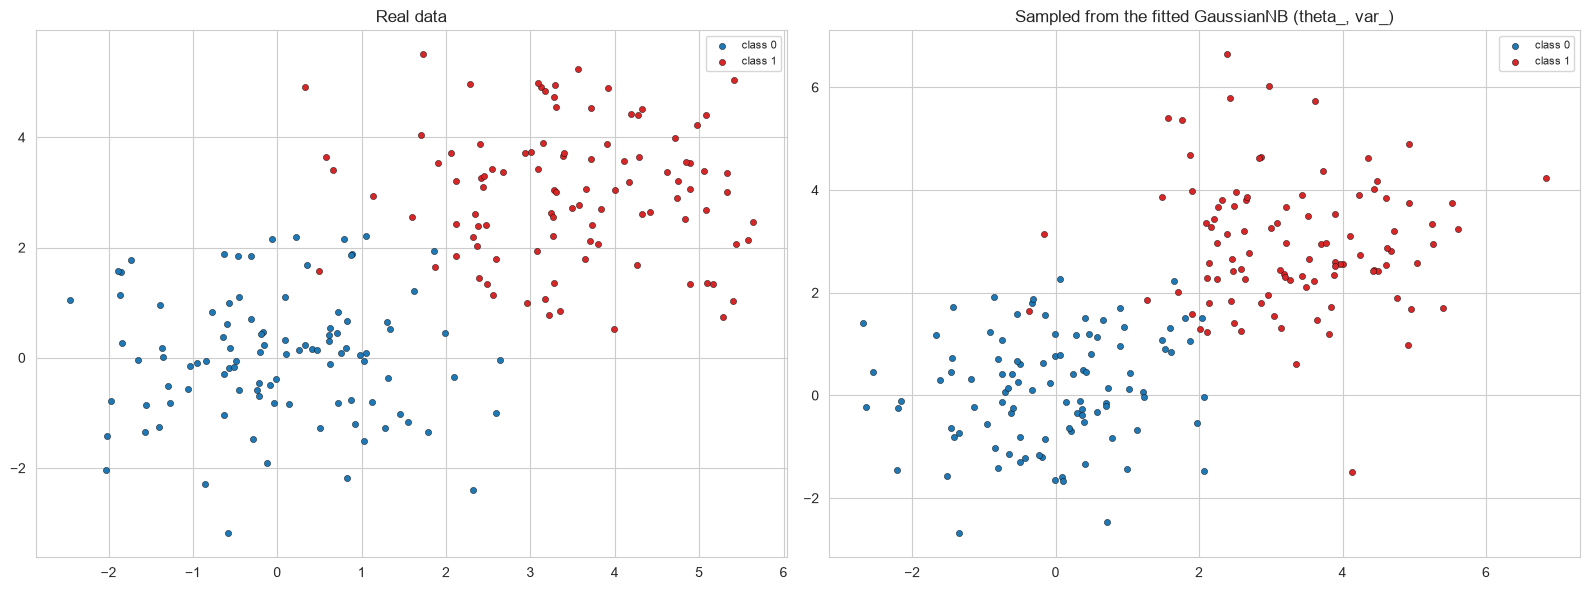

💡 The fitted model is a generative story: 'class c draws each feature from its own N(mu, var)'.
   The samples reproduce the blobs' location and spread but not any feature correlation — the
   same axis-aligned geometry as §5. A discriminative model simply cannot produce this picture.


In [15]:
X_gen, y_gen = make_blobs(n_samples=200, centers=[[0.0, 0.0], [3.5, 3.0]],
                          cluster_std=1.2, random_state=11)
nb_gen = GaussianNB().fit(X_gen, y_gen)

rng_gen = np.random.default_rng(0)
X_samp = np.empty_like(X_gen)
y_samp = np.empty_like(y_gen)
for c_g, cls_g in enumerate(nb_gen.classes_):
    mask_g = y_gen == cls_g
    X_samp[mask_g] = rng_gen.normal(nb_gen.theta_[c_g], np.sqrt(nb_gen.var_[c_g]),
                                    size=(int(mask_g.sum()), 2))
    y_samp[mask_g] = cls_g

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for label_g, color_g in zip(np.unique(y_gen), ["#1f77b4", "#d62728"]):
    axes[0].scatter(X_gen[y_gen == label_g, 0], X_gen[y_gen == label_g, 1], c=color_g, s=20,
                    edgecolors="k", linewidths=0.3, label=f"class {label_g}")
    axes[1].scatter(X_samp[y_samp == label_g, 0], X_samp[y_samp == label_g, 1], c=color_g, s=20,
                    edgecolors="k", linewidths=0.3, label=f"class {label_g}")
axes[0].set_title("Real data")
axes[0].legend(fontsize=8)
axes[1].set_title("Sampled from the fitted GaussianNB (theta_, var_)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("💡 The fitted model is a generative story: 'class c draws each feature from its own N(mu, var)'.")
print("   The samples reproduce the blobs' location and spread but not any feature correlation — the")
print("   same axis-aligned geometry as §5. A discriminative model simply cannot produce this picture.")

### Multinomial & Bernoulli: the Text Variants (scikit-learn only)

The canonical Naive Bayes use case is text, and the text variants are a different *event model*, not a different algorithm:

- **`MultinomialNB`** — features are **counts** (how many times each word appeared). The likelihood is a multinomial over the vocabulary
- **`BernoulliNB`** — features are **binary** (did the word appear at all). It also models word *absence*, which often helps on short texts
- **`ComplementNB`** — a Multinomial variant built for imbalanced text classification

All three share the additive smoothing parameter **`alpha`**: unseen words must not get probability exactly zero, or a single new word would zero out a whole class's likelihood. `alpha` is the count-model analogue of the Gaussian variance floor.

The twin is Gaussian-only, so this subsection and the next run on scikit-learn. The corpus below is built in the notebook — deterministic, no network downloads.

24 messages x 79 vocabulary words (sparse matrix, 164 non-zero entries)


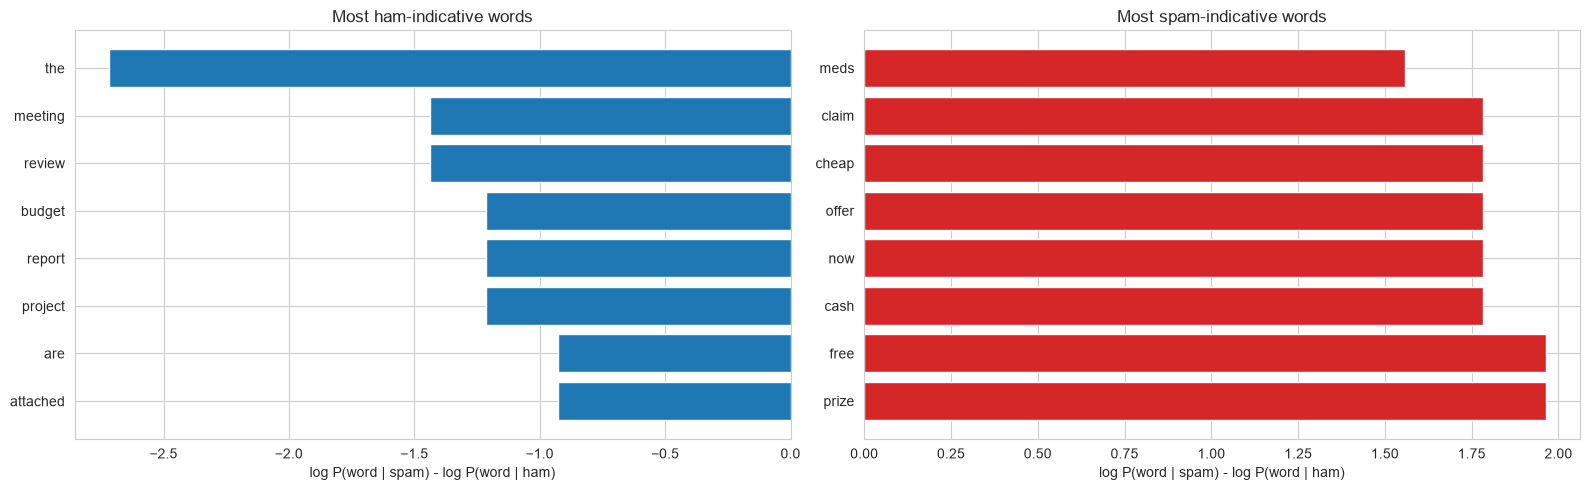

                           message  P(spam) MultinomialNB  P(spam) BernoulliNB MultinomialNB says BernoulliNB says
    claim your free cash prize now               0.999972             0.999997               spam             spam
please review the meeting schedule               0.000417             0.000013                ham              ham
        cheap meds offer buy today               0.999113             0.999701               spam             spam
      thanks for the project notes               0.000868             0.000031                ham              ham

💡 The classifier knows words, not grammar: each word votes with its log-probability and the
   sum decides. The bar chart above IS the model's explanation — no SHAP, no coefficient
   gymnastics. Note how the two event models can disagree on a borderline message.


In [16]:
# A tiny in-notebook corpus: 24 labelled messages. Deterministic, no network.
spam_msgs = [
    "free cash prize winner claim now",
    "limited offer buy cheap meds online today",
    "click here to claim your free prize",
    "winner selected claim your cash prize today",
    "urgent cheap meds offer limited time only",
    "free entry to win a big cash prize click now",
    "buy now pay later best cheap offer",
    "claim your free vacation prize today",
    "limited cash offer for winners click now",
    "cheap meds deal buy today free shipping",
]
ham_msgs = [
    "can we move the meeting to friday morning",
    "the project review is scheduled for monday",
    "please review the report before lunch",
    "thanks for sending the updated schedule",
    "the team meeting notes are attached",
    "lunch tomorrow to discuss the budget",
    "could you review my pull request today",
    "the deadline for the report is next week",
    "the manager approved the project budget",
    "thanks all for the great meeting today",
    "attached are the notes from the review meeting",
    "the schedule for the next sprint looks good",
    "please send me the updated report tonight",
    "can we discuss the project budget on friday",
]
corpus = spam_msgs + ham_msgs
labels_txt = np.array([1] * len(spam_msgs) + [0] * len(ham_msgs))   # 1 = spam, 0 = ham

vec_txt = CountVectorizer()
X_txt = vec_txt.fit_transform(corpus)
vocab_txt = vec_txt.get_feature_names_out()
print(f"{len(corpus)} messages x {X_txt.shape[1]} vocabulary words "
      f"(sparse matrix, {X_txt.nnz} non-zero entries)")

mn_txt = MultinomialNB().fit(X_txt, labels_txt)
bn_txt = BernoulliNB().fit(X_txt, labels_txt)

# The free interpretability: per-word log P(word | class), differenced between classes
log_odds_txt = mn_txt.feature_log_prob_[1] - mn_txt.feature_log_prob_[0]
order_txt = np.argsort(log_odds_txt)
top_ham_w = vocab_txt[order_txt[:8]]
top_spam_w = vocab_txt[order_txt[::-1][:8]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(range(8), np.sort(log_odds_txt)[:8][::-1], color="#1f77b4")
axes[0].set_yticks(range(8), top_ham_w[::-1])
axes[0].set_xlabel("log P(word | spam) - log P(word | ham)")
axes[0].set_title("Most ham-indicative words")
axes[1].barh(range(8), np.sort(log_odds_txt)[::-1][:8], color="#d62728")
axes[1].set_yticks(range(8), top_spam_w)
axes[1].set_xlabel("log P(word | spam) - log P(word | ham)")
axes[1].set_title("Most spam-indicative words")
plt.tight_layout()
plt.show()

new_msgs = ["claim your free cash prize now",
            "please review the meeting schedule",
            "cheap meds offer buy today",
            "thanks for the project notes"]
X_new = vec_txt.transform(new_msgs)
rows_new = []
for msg_n, p_mn, p_bn in zip(new_msgs,
                             mn_txt.predict_proba(X_new)[:, 1],
                             bn_txt.predict_proba(X_new)[:, 1]):
    rows_new.append({"message": msg_n, "P(spam) MultinomialNB": p_mn,
                     "P(spam) BernoulliNB": p_bn,
                     "MultinomialNB says": "spam" if p_mn >= 0.5 else "ham",
                     "BernoulliNB says": "spam" if p_bn >= 0.5 else "ham"})
print(pd.DataFrame(rows_new).to_string(index=False))
print("\n💡 The classifier knows words, not grammar: each word votes with its log-probability and the")
print("   sum decides. The bar chart above IS the model's explanation — no SHAP, no coefficient")
print("   gymnastics. Note how the two event models can disagree on a borderline message.")

---

## 7. Hyperparameter Tuning

Naive Bayes has almost no tuning surface, and that is a feature:

1. **Gaussian**: `var_smoothing` (numerical insurance, §5) and `priors` (the class-imbalance lever). That is the entire list
2. **Count models**: `alpha` — the smoothing that stands in for words you have not seen yet
3. There is no depth, no C, no kernel, no learning rate: NB cannot trade capacity for accuracy. Its performance profile is decided by the **variant choice** and the **feature quality**, not by tuning

The same rules as every notebook: search on log scales, tune with stratified cross-validation on training data only, and keep the test set for the final report.

 var_smoothing  CV accuracy  ± std  mean max posterior (train)
        0.0000       0.8800 0.0306                      0.9024
        0.0000       0.8800 0.0306                      0.9024
        0.0000       0.8800 0.0306                      0.9024
        0.0000       0.8800 0.0306                      0.9024
        0.0000       0.8800 0.0306                      0.9024
        0.0000       0.8800 0.0306                      0.9024
        0.0000       0.8800 0.0306                      0.9024
        0.0000       0.8800 0.0306                      0.9024
        0.0001       0.8800 0.0306                      0.9024
        0.0010       0.8800 0.0306                      0.9021
        0.0100       0.8800 0.0306                      0.8986
        0.1000       0.8733 0.0389                      0.8655


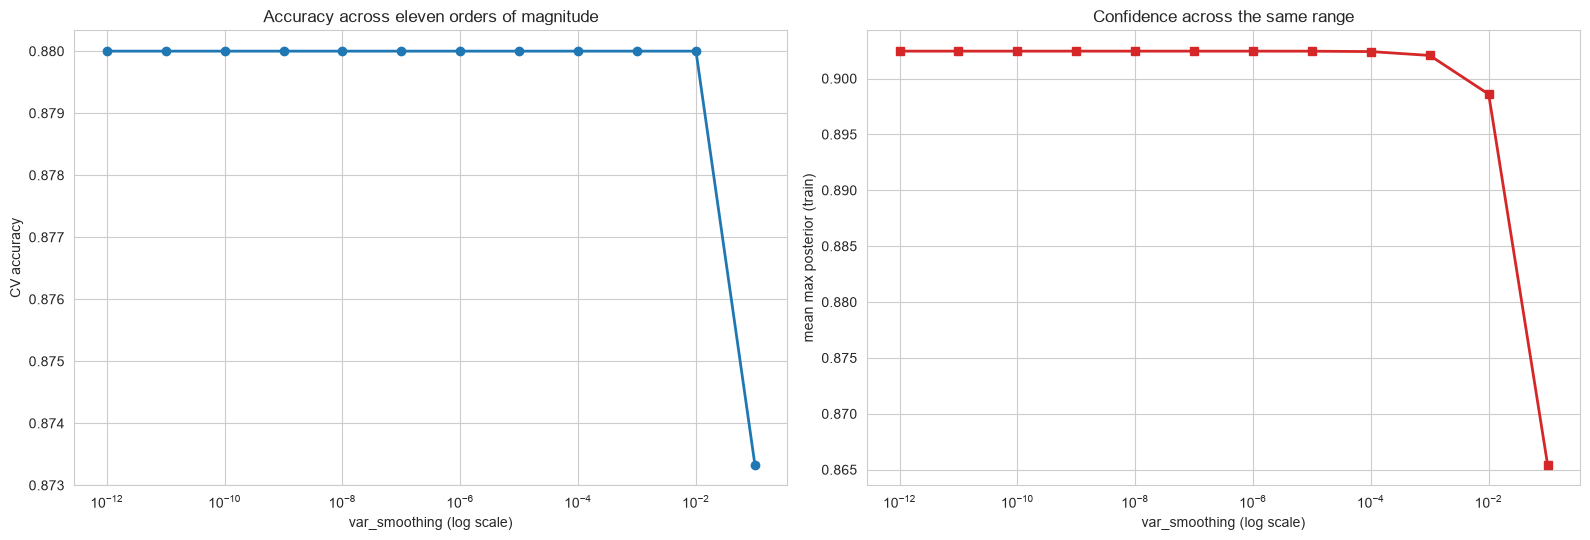


💡 Same lesson as the scratch sweep, now cross-validated: var_smoothing moves confidence, not
   decisions. There is no tuning gain to hunt here — leave it at 1e-9 unless a near-constant
   feature or a degenerate variance forces the issue.


In [17]:
# The var_smoothing sweep, now cross-validated on a noisier moons set
X_tune, y_tune = make_moons(n_samples=400, noise=0.25, random_state=3)
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_tune, y_tune, test_size=0.25,
                                              stratify=y_tune, random_state=42)

cv_s = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smooth_grid = np.logspace(-12, -1, 12)
rows_v = []
for s_val in smooth_grid:
    scores_v = cross_val_score(GaussianNB(var_smoothing=s_val), Xt_tr, yt_tr,
                               cv=cv_s, scoring="accuracy")
    conf_v = GaussianNB(var_smoothing=s_val).fit(Xt_tr, yt_tr).predict_proba(Xt_tr).max(axis=1).mean()
    rows_v.append({"var_smoothing": s_val, "CV accuracy": scores_v.mean(),
                   "± std": scores_v.std(), "mean max posterior (train)": conf_v})
v_df = pd.DataFrame(rows_v)
print(v_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].semilogx(v_df["var_smoothing"], v_df["CV accuracy"], "o-", color="#1f77b4", lw=2)
axes[0].set_xlabel("var_smoothing (log scale)")
axes[0].set_ylabel("CV accuracy")
axes[0].set_title("Accuracy across eleven orders of magnitude")
axes[1].semilogx(v_df["var_smoothing"], v_df["mean max posterior (train)"], "s-",
                 color="#d62728", lw=2)
axes[1].set_xlabel("var_smoothing (log scale)")
axes[1].set_ylabel("mean max posterior (train)")
axes[1].set_title("Confidence across the same range")
plt.tight_layout()
plt.show()

print("\n💡 Same lesson as the scratch sweep, now cross-validated: var_smoothing moves confidence, not")
print("   decisions. There is no tuning gain to hunt here — leave it at 1e-9 unless a near-constant")
print("   feature or a degenerate variance forces the issue.")

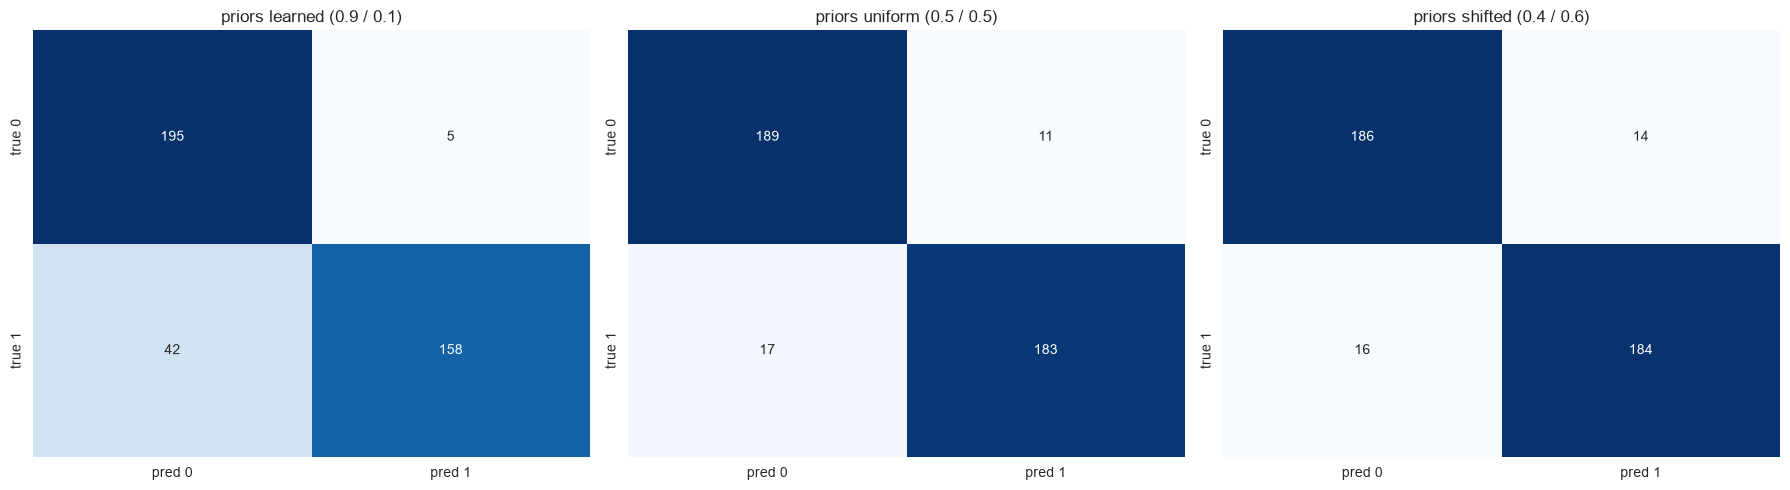

             priors  accuracy  recall class 0  recall class 1
learned (0.9 / 0.1)    0.8825          0.9750          0.7900
uniform (0.5 / 0.5)    0.9300          0.9450          0.9150
shifted (0.4 / 0.6)    0.9250          0.9300          0.9200

💡 The priors shift the boundary toward the class you claim is more common, without touching the
   likelihoods — NB's answer to class_weight. Tune them on training CV, never on the test set.
   (The scratch twin always learns priors from the labels; this lever is sklearn-only.)


In [18]:
# The priors lever: imbalanced training set (900 / 100), balanced test set (200 / 200)
rng_p = np.random.default_rng(7)
X0_p = rng_p.normal([0.0, 0.0], 1.4, size=(900, 2))
X1_p = rng_p.normal([3.0, 3.0], 1.4, size=(100, 2))
Xp_tr = np.r_[X0_p, X1_p]
yp_tr = np.r_[np.zeros(900, int), np.ones(100, int)]
X0_te = rng_p.normal([0.0, 0.0], 1.4, size=(200, 2))
X1_te = rng_p.normal([3.0, 3.0], 1.4, size=(200, 2))
Xp_te = np.r_[X0_te, X1_te]
yp_te = np.r_[np.zeros(200, int), np.ones(200, int)]

prior_sets = [("learned (0.9 / 0.1)", None), ("uniform (0.5 / 0.5)", [0.5, 0.5]),
              ("shifted (0.4 / 0.6)", [0.4, 0.6])]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
rows_p = []
for ax, (name_p, priors_p) in zip(axes, prior_sets):
    m_p = GaussianNB(priors=priors_p).fit(Xp_tr, yp_tr)
    pred_p = m_p.predict(Xp_te)
    rows_p.append({"priors": name_p, "accuracy": accuracy_score(yp_te, pred_p),
                   "recall class 0": (pred_p[yp_te == 0] == 0).mean(),
                   "recall class 1": (pred_p[yp_te == 1] == 1).mean()})
    cm_p = confusion_matrix(yp_te, pred_p)
    sns.heatmap(cm_p, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["pred 0", "pred 1"], yticklabels=["true 0", "true 1"])
    ax.set_title(f"priors {name_p}")
plt.tight_layout()
plt.show()

print(pd.DataFrame(rows_p).to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\n💡 The priors shift the boundary toward the class you claim is more common, without touching the")
print("   likelihoods — NB's answer to class_weight. Tune them on training CV, never on the test set.")
print("   (The scratch twin always learns priors from the labels; this lever is sklearn-only.)")

    alpha  corpus accuracy  P(unseen word | spam)
 0.001000         1.000000               0.000014
 0.010000         1.000000               0.000141
 0.100000         1.000000               0.001284
 1.000000         1.000000               0.006711
10.000000         1.000000               0.011628


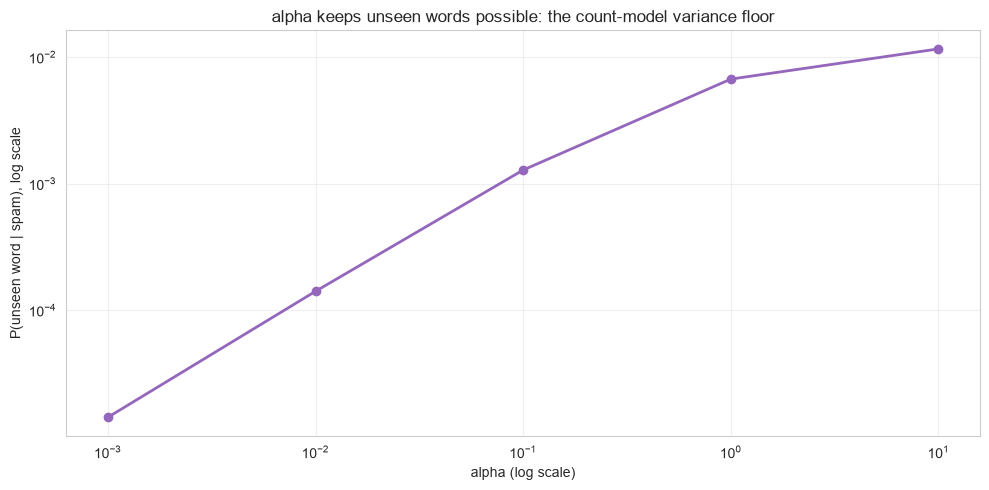


💡 With alpha = 1 (Laplace smoothing) a word never seen in the spam class still gets a small,
   non-zero probability, so a new message containing it can never be ruled out of a class.
   alpha and var_smoothing are the same lesson in two event models: keep the log probabilities
   finite, and keep the confidence honest.


In [19]:
# The count-model smoothing sweep: alpha is the 'out-of-vocabulary' allowance
alpha_grid = [0.001, 0.01, 0.1, 1.0, 10.0]
total_words_spam = int(X_txt[labels_txt == 1].sum())
V_txt = X_txt.shape[1]

rows_a = []
for a_val in alpha_grid:
    mn_a = MultinomialNB(alpha=a_val).fit(X_txt, labels_txt)
    # A word never seen in the spam class gets P = alpha / (total spam words + alpha * V)
    p_unseen = a_val / (total_words_spam + a_val * V_txt)
    rows_a.append({"alpha": a_val, "corpus accuracy": mn_a.score(X_txt, labels_txt),
                   "P(unseen word | spam)": p_unseen})
a_df = pd.DataFrame(rows_a)
print(a_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(a_df["alpha"], a_df["P(unseen word | spam)"], "o-", color="#9467bd", lw=2)
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("P(unseen word | spam), log scale")
ax.set_title("alpha keeps unseen words possible: the count-model variance floor")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 With alpha = 1 (Laplace smoothing) a word never seen in the spam class still gets a small,")
print("   non-zero probability, so a new message containing it can never be ruled out of a class.")
print("   alpha and var_smoothing are the same lesson in two event models: keep the log probabilities")
print("   finite, and keep the confidence honest.")

---

## 8. Complete Hyperparameter Reference

### GaussianNB Parameters (scikit-learn 1.9)

#### `priors` (array-like of shape (n_classes,), default=None) **[THE IMBALANCE LEVER]**
- **Description**: class prior probabilities. If None, learned from the training label frequencies
- **Constraints**: must sum to 1 and be non-negative (validated at fit)
- **Effect**: shifts the decision boundary toward the class given more prior mass; the likelihoods never change
- **Tuning strategy**: leave at None unless the training labels misrepresent deployment, or classes are imbalanced and you evaluate on a balanced set (§7)
- **Example**: `GaussianNB(priors=[0.5, 0.5])`

#### `var_smoothing` (float, default=1e-9) **[THE ONLY OTHER KNOB]**
- **Description**: share of the largest feature variance added to every per-class variance: `epsilon_ = var_smoothing * X.var(axis=0).max()`
- **Effect**: floors every variance, flattening confidence peaks; protects against near-constant features that would otherwise dominate every decision
- **Tuning strategy**: accuracy is nearly flat across orders of magnitude (§7). Treat it as numerical insurance, not a fit knob
- **Example**: `GaussianNB(var_smoothing=1e-3)` when a feature is nearly constant in one class

`fit` also accepts `sample_weight` (per-row weights), and `partial_fit` enables incremental/streaming updates — neither is implemented in the twin.

### MultinomialNB (count features)

| Parameter | Default | What it does |
|---|---|---|
| `alpha` | 1.0 | additive (Laplace/Lidstone) smoothing on the counts; the out-of-vocabulary allowance (§7) |
| `force_alpha` | True | older defaults allowed tiny alphas to vanish; keep True |
| `fit_prior` | True | learn class priors from the data |
| `class_prior` | None | override the priors (same lever as GaussianNB's `priors`) |

Requires non-negative values. Standardized (negative) features raise a `ValueError` — see §9.

### BernoulliNB (binary features)

- Same smoothing parameters as MultinomialNB plus **`binarize`** (float, default 0.0): values above it become 1, the rest 0. On already-binary features leave it at 0.0
- Models word *absence* as well as presence — often better when documents are short

### ComplementNB (imbalanced text)

- Same parameters plus **`norm`** (bool, default False): weight normalisation of the complement counts. Designed for imbalanced text classification, where it frequently beats MultinomialNB

### CategoricalNB (categorical features)

- Each feature becomes a categorical distribution over its integer codes; same smoothing parameters plus **`min_categories`**. Features must be non-negative integer codes — encode with `OrdinalEncoder` first

### Parameter Combination Recipes

#### Baseline (always start here):
```python
GaussianNB()                     # no scaling, no tuning — the floor for every other model
```

#### Near-constant feature:
```python
GaussianNB(var_smoothing=1e-3)
```

#### Imbalanced classes:
```python
GaussianNB(priors=[0.5, 0.5])    # evaluate on a balanced set to see the effect
```

#### Text (counts):
```python
Pipeline([("vec", CountVectorizer()), ("clf", MultinomialNB(alpha=1.0))])
```

#### Short texts / binary presence:
```python
Pipeline([("vec", CountVectorizer()), ("clf", BernoulliNB(binarize=0.0))])
```

#### Imbalanced text:
```python
Pipeline([("vec", CountVectorizer()), ("clf", ComplementNB())])
```

### Scratch Twin Coverage

| scikit-learn `GaussianNB` parameter | Scratch twin | Notes |
|---|---|---|
| `var_smoothing` | ✅ | same meaning, same formula |
| `priors` | ❌ | priors always learned from the labels |
| `sample_weight` (fit) | ❌ | not implemented |
| `partial_fit` | ❌ | closed-form batch fit only |
| MultinomialNB / BernoulliNB / ComplementNB / CategoricalNB | ❌ | Gaussian only, by design |

Everything else the twin mirrors exactly: `classes_`, `class_prior_`, `theta_`, `var_`, `epsilon_`, and exact numeric agreement with sklearn (§6).

---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **Match the Variant to the Feature Type**
The variant is not a detail — it *is* the model.

| Feature type | Variant |
|---|---|
| Continuous measurements | `GaussianNB` |
| Word/event counts | `MultinomialNB` |
| Binary presence/absence | `BernoulliNB` |
| Non-negative integer codes | `CategoricalNB` (after `OrdinalEncoder`) |

---

#### 2. **Fit NB First, Whatever You Plan to Use**
It trains in one pass and gives you the accuracy floor every other model must beat. A fancy model that scores below GaussianNB has a bug or a leakage problem.

---

#### 3. **Check the Probabilities Before Consuming Them**
NB posteriors are exact Bayes computations of a *wrong* model. Under correlated features they are systematically overconfident (§3, §10 Example 1). A reliability diagram is one line:

```python
from sklearn.calibration import calibration_curve
fraction_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8)
```

---

#### 4. **Drop Redundant Features Rather Than Fighting Them**
Radius, perimeter and area of a tumor are one measurement wearing three outfits. NB counts that evidence three times. Keep one, or switch to logistic regression, which shares the credit across correlated features.

---

#### 5. **Use the Prior as the Imbalance Lever**
`priors` (Gaussian) / `class_prior` (count variants) shift the boundary toward the under-represented class without resampling or reweighting the likelihoods. Tune them with CV like any hyperparameter.

---

#### 6. **Transform Heavy-Tailed Features Before GaussianNB**
The per-class mean and variance are moment estimators: one extreme value moves both. Log-transform skewed positive features (income, durations, counts), or bin heavy-tailed features into categories for CategoricalNB.

---

#### 7. **Read the Log-Odds on Text Problems**
`feature_log_prob_` holds log P(word | class) — the difference between two classes' rows is a per-word explanation of every decision. The §6 bar chart is the whole story.

---

#### 8. **Do Not Scale "Just in Case"**
GaussianNB is scale-invariant: standardizing changes nothing, so the scaler is dead weight. And for MultinomialNB a scaler is worse than dead weight — it raises (§9, mistake 2).

### ❌ Common Mistakes

#### 1. **Using GaussianNB on Count or Binary Features**
```python
# BAD:  GaussianNB().fit(X_counts, y)      # models counts with a normal: variance explodes
# GOOD: MultinomialNB().fit(X_counts, y)   # the counts are the model
```

---

#### 2. **Feeding Standardized (Negative) Features to MultinomialNB**
```python
# BAD:  Pipeline([("sc", StandardScaler()), ("clf", MultinomialNB())])    # ValueError: negative values
# GOOD: Pipeline([("vec", CountVectorizer()), ("clf", MultinomialNB())])  # counts stay counts
```

---

#### 3. **Trusting the Probabilities Under Correlated Features**
```python
# BAD:  ship P(spam) = 0.9999 from a model whose features share evidence
# GOOD: check the reliability diagram first; calibrate or use logistic regression if it matters
```

---

#### 4. **Tuning var_smoothing for Accuracy**
It is a numerical floor, not a fit knob (§7). Accuracy will not move; the confidence will.

---

#### 5. **Tuning Priors on the Test Set**
The prior shifts every decision — tuning it against test labels is the same leak as tuning C there. Use training CV.

---

#### 6. **Expecting NB to Represent Interactions**
The likelihood is a product of one-feature terms: "cheap AND urgent together" cannot be more (or less) than the product of the two. Engineer the interaction as a feature, or use a model that can represent it.

### Debugging Recipes

#### Probabilities Stuck Near 0 / 1?
1. Look for correlated or duplicated features — NB is double-counting shared evidence (§3 demo)
2. Drop redundant features and re-check the mean max posterior
3. Try logistic regression on the same features: if its probabilities are sane, dependence was the cause

#### Accuracy Poor on Continuous Features?
1. Plot per-feature histograms per class — GaussianNB wants roughly unimodal, symmetric class-conditionals
2. Log-transform skewed positive features (income, durations, counts)
3. Try `QuadraticDiscriminantAnalysis` (models full covariance) or logistic regression
4. Check you did not feed counts to GaussianNB — the variant-feature mismatch again

#### Accuracy Poor on Text?
1. Sweep alpha (§7); small corpora like bigger alpha
2. Check tokenization: `CountVectorizer` drops one-character tokens by default
3. Imbalanced classes? Try `ComplementNB`
4. Compare against a linear model on TF-IDF features before concluding NB is wrong for the task

#### `ValueError: Negative values in data passed to MultinomialNB input`?
1. You scaled counts. Remove the scaler, or switch to `MinMaxScaler` if scaling is truly needed
2. Or use GaussianNB for continuous features

#### `ValueError: Input contains NaN`?
1. GaussianNB validates finiteness — impute first (`SimpleImputer`)
2. Check for infinities too (`np.isfinite(X).all()`)

#### NB Well Below Other Models on the Same Data?
1. That is often just true — independence is a strong assumption (§11's moons column)
2. NB's job is the baseline and the speed; keep its score as the floor and move on

---

## 10. Real-world Examples

Two examples chosen as a **pair of contrasts**:

- **Example 1: Breast Cancer Diagnosis (binary, medical).** Thirty numeric features, several of them highly correlated (radius, perimeter and area measure the same tumor three times). The workflow: fit, per-class report, and a reliability diagram that shows the independence lesson on real data — compared against logistic regression, the calibrated alternative.
- **Example 2: Handwritten Digits (multiclass, 10 classes).** The same 8×8 pixels through two NB event models: `GaussianNB` treating pixel intensities as continuous values, and `MultinomialNB` treating them as non-negative counts. Same data, two event models, visibly different accuracy.

Both datasets are bundled with scikit-learn — no network downloads. Both run on scikit-learn at full size; the scratch twin stays in §5–§6 where it belongs.

### Example 1: Breast Cancer Diagnosis (Binary)

The Wisconsin Breast Cancer dataset has 569 tumors described by 30 numeric features. The label is malignant (0) or benign (1); as in notebook 05, benign is the positive class, so the summary metrics describe benign detection. No scaler — Gaussian NB does not need one.

In [20]:
bc_nb = load_breast_cancer()
Xb_tr_nb, Xb_te_nb, yb_tr_nb, yb_te_nb = train_test_split(bc_nb.data, bc_nb.target,
                                                          test_size=0.25, stratify=bc_nb.target,
                                                          random_state=42)

print("=" * 60)
print("REAL-WORLD EXAMPLE: BREAST CANCER (GAUSSIAN NB)")
print("=" * 60)
print(f"\n📊 {len(bc_nb.target)} tumors x {bc_nb.data.shape[1]} features")
print(f"   malignant (0): {np.sum(bc_nb.target == 0)}   benign (1): {np.sum(bc_nb.target == 1)}")
print(f"   Train/test: {len(yb_tr_nb)} / {len(yb_te_nb)} (stratified)")

nb_bc = GaussianNB().fit(Xb_tr_nb, yb_tr_nb)
pred_bc_nb = nb_bc.predict(Xb_te_nb)
proba_bc_nb = nb_bc.predict_proba(Xb_te_nb)[:, 1]

print(f"\n✨ Test accuracy: {accuracy_score(yb_te_nb, pred_bc_nb):.4f}")
print(f"✨ ROC-AUC (benign = positive class): {roc_auc_score(yb_te_nb, proba_bc_nb):.4f}")
print("   Per-class report (the summary numbers above describe class 1 = benign):")
print(classification_report(yb_te_nb, pred_bc_nb, target_names=["malignant", "benign"]))

missed_nb = int(np.sum((yb_te_nb == 0) & (pred_bc_nb == 1)))
false_alarms_nb = int(np.sum((yb_te_nb == 1) & (pred_bc_nb == 0)))
print(f"Malignant tumors missed (false negatives): {missed_nb}")
print(f"Benign tumors flagged as malignant (false positives): {false_alarms_nb}")

# The independence lesson on real data: which feature pairs correlate most?
corr_b = np.corrcoef(bc_nb.data, rowvar=False)
iu_b = np.triu_indices_from(corr_b, k=1)
order_b = np.argsort(np.abs(corr_b[iu_b]))[::-1][:3]
print("\n🔍 Strongest feature-pair correlations (the evidence NB double-counts):")
for k_b in order_b:
    i_b, j_b = iu_b[0][k_b], iu_b[1][k_b]
    print(f"   {bc_nb.feature_names[i_b]} & {bc_nb.feature_names[j_b]}: r = {corr_b[i_b, j_b]:.3f}")

REAL-WORLD EXAMPLE: BREAST CANCER (GAUSSIAN NB)

📊 569 tumors x 30 features
   malignant (0): 212   benign (1): 357
   Train/test: 426 / 143 (stratified)

✨ Test accuracy: 0.9371
✨ ROC-AUC (benign = positive class): 0.9893
   Per-class report (the summary numbers above describe class 1 = benign):
              precision    recall  f1-score   support

   malignant       0.96      0.87      0.91        53
      benign       0.93      0.98      0.95        90

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143

Malignant tumors missed (false negatives): 7
Benign tumors flagged as malignant (false positives): 2

🔍 Strongest feature-pair correlations (the evidence NB double-counts):
   mean radius & mean perimeter: r = 0.998
   worst radius & worst perimeter: r = 0.994
   mean radius & mean area: r = 0.987


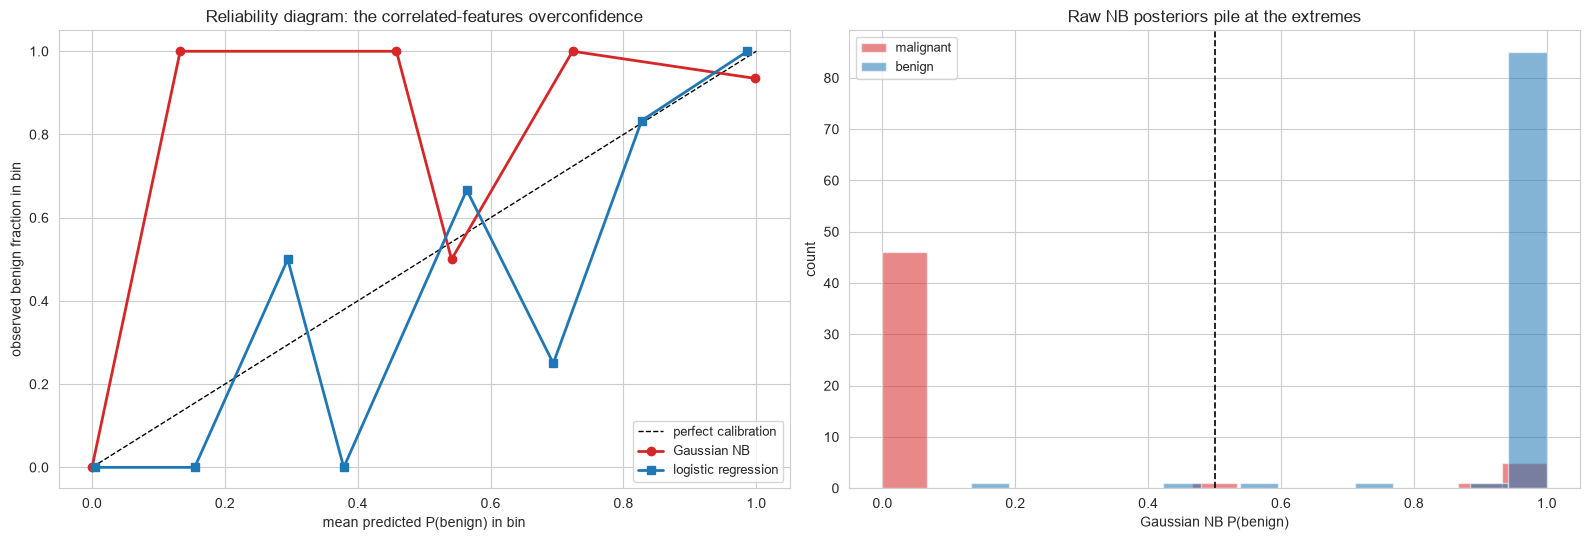

model                  | accuracy | log loss |  Brier
Gaussian NB (raw)      |   0.9371 |   0.3671 | 0.0519
Logistic regression    |   0.9580 |   0.0872 | 0.0280

💡 Read the two rows together: similar accuracy, meaningfully worse log loss and Brier for NB.
   That is §3's correlated-features lesson on real medical data. If the decision consumes the
   probability, calibrate or switch; if it consumes only the class, NB is fine as it is.


In [21]:
lr_bc_nb = LogisticRegression(max_iter=5000).fit(Xb_tr_nb, yb_tr_nb)
proba_lr_nb = lr_bc_nb.predict_proba(Xb_te_nb)[:, 1]

brier_nb = brier_score_loss(yb_te_nb, proba_bc_nb)
brier_lr = brier_score_loss(yb_te_nb, proba_lr_nb)
ll_nb = log_loss(yb_te_nb, proba_bc_nb)
ll_lr = log_loss(yb_te_nb, proba_lr_nb)

frac_nb, mean_nb = calibration_curve(yb_te_nb, proba_bc_nb, n_bins=8)
frac_lr, mean_lr = calibration_curve(yb_te_nb, proba_lr_nb, n_bins=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
axes[0].plot(mean_nb, frac_nb, "o-", color="#d62728", lw=2, label="Gaussian NB")
axes[0].plot(mean_lr, frac_lr, "s-", color="#1f77b4", lw=2, label="logistic regression")
axes[0].set_xlabel("mean predicted P(benign) in bin")
axes[0].set_ylabel("observed benign fraction in bin")
axes[0].set_title("Reliability diagram: the correlated-features overconfidence")
axes[0].legend(fontsize=9)

axes[1].hist(proba_bc_nb[yb_te_nb == 0], bins=15, alpha=0.55, color="#d62728", label="malignant")
axes[1].hist(proba_bc_nb[yb_te_nb == 1], bins=15, alpha=0.55, color="#1f77b4", label="benign")
axes[1].axvline(0.5, color="black", ls="--", lw=1.2)
axes[1].set_xlabel("Gaussian NB P(benign)")
axes[1].set_ylabel("count")
axes[1].set_title("Raw NB posteriors pile at the extremes")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'model':<22s} | {'accuracy':>8s} | {'log loss':>8s} | {'Brier':>6s}")
print(f"{'Gaussian NB (raw)':<22s} | {accuracy_score(yb_te_nb, pred_bc_nb):8.4f} | {ll_nb:8.4f} | {brier_nb:6.4f}")
print(f"{'Logistic regression':<22s} | {lr_bc_nb.score(Xb_te_nb, yb_te_nb):8.4f} | {ll_lr:8.4f} | {brier_lr:6.4f}")
print("\n💡 Read the two rows together: similar accuracy, meaningfully worse log loss and Brier for NB.")
print("   That is §3's correlated-features lesson on real medical data. If the decision consumes the")
print("   probability, calibrate or switch; if it consumes only the class, NB is fine as it is.")

### Example 2: Handwritten Digits (10 Classes, Two Event Models on the Same Pixels)

The digits dataset has 1,797 images of 8×8 pixels, values 0–16 — non-negative integers, so they are simultaneously continuous measurements **and** counts. That makes it the rare dataset where both NB variants are legal on the raw features, and the comparison between them is a lesson in event models rather than in preprocessing.

In [22]:
digits_nb = load_digits()
idx_all_nb = np.arange(len(digits_nb.target))
idx_tr_nb, idx_te_nb = train_test_split(idx_all_nb, test_size=0.25,
                                        stratify=digits_nb.target, random_state=42)
Xd_tr_nb, Xd_te_nb = digits_nb.data[idx_tr_nb], digits_nb.data[idx_te_nb]
yd_tr_nb, yd_te_nb = digits_nb.target[idx_tr_nb], digits_nb.target[idx_te_nb]

print("=" * 60)
print("REAL-WORLD EXAMPLE: HANDWRITTEN DIGITS (TWO NB EVENT MODELS)")
print("=" * 60)
print(f"\n📊 {len(digits_nb.target)} images x {digits_nb.data.shape[1]} pixels (8x8), 10 classes")
print("   pixel values 0..16 — non-negative, so BOTH variants fit the raw features")

nb_gauss_d = GaussianNB().fit(Xd_tr_nb, yd_tr_nb)
nb_multin_d = MultinomialNB().fit(Xd_tr_nb, yd_tr_nb)

acc_gauss_d = nb_gauss_d.score(Xd_te_nb, yd_te_nb)
acc_multin_d = nb_multin_d.score(Xd_te_nb, yd_te_nb)
print(f"\n📊 Test accuracy:")
print(f"  GaussianNB    (each pixel a normal):     {acc_gauss_d:.4f}")
print(f"  MultinomialNB (each pixel a count):      {acc_multin_d:.4f}")
print("\n📋 MultinomialNB classification report:")
print(classification_report(yd_te_nb, nb_multin_d.predict(Xd_te_nb), digits=3))

REAL-WORLD EXAMPLE: HANDWRITTEN DIGITS (TWO NB EVENT MODELS)

📊 1797 images x 64 pixels (8x8), 10 classes
   pixel values 0..16 — non-negative, so BOTH variants fit the raw features

📊 Test accuracy:
  GaussianNB    (each pixel a normal):     0.8289
  MultinomialNB (each pixel a count):      0.8822

📋 MultinomialNB classification report:
              precision    recall  f1-score   support

           0      1.000     0.956     0.977        45
           1      0.727     0.696     0.711        46
           2      0.851     0.909     0.879        44
           3      0.978     0.957     0.967        46
           4      0.935     0.956     0.945        45
           5      0.973     0.783     0.867        46
           6      0.977     0.956     0.966        45
           7      0.833     1.000     0.909        45
           8      0.857     0.837     0.847        43
           9      0.729     0.778     0.753        45

    accuracy                          0.882       450
   macro a

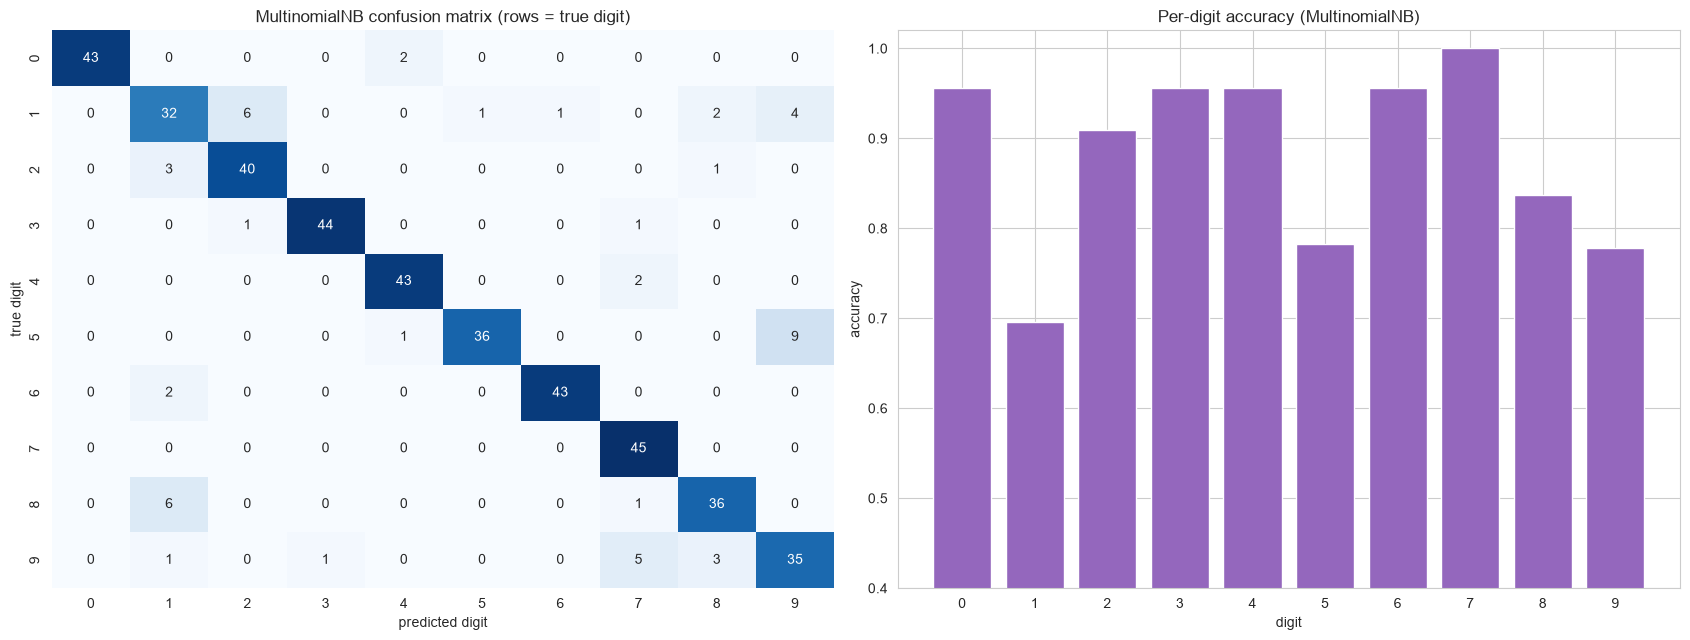

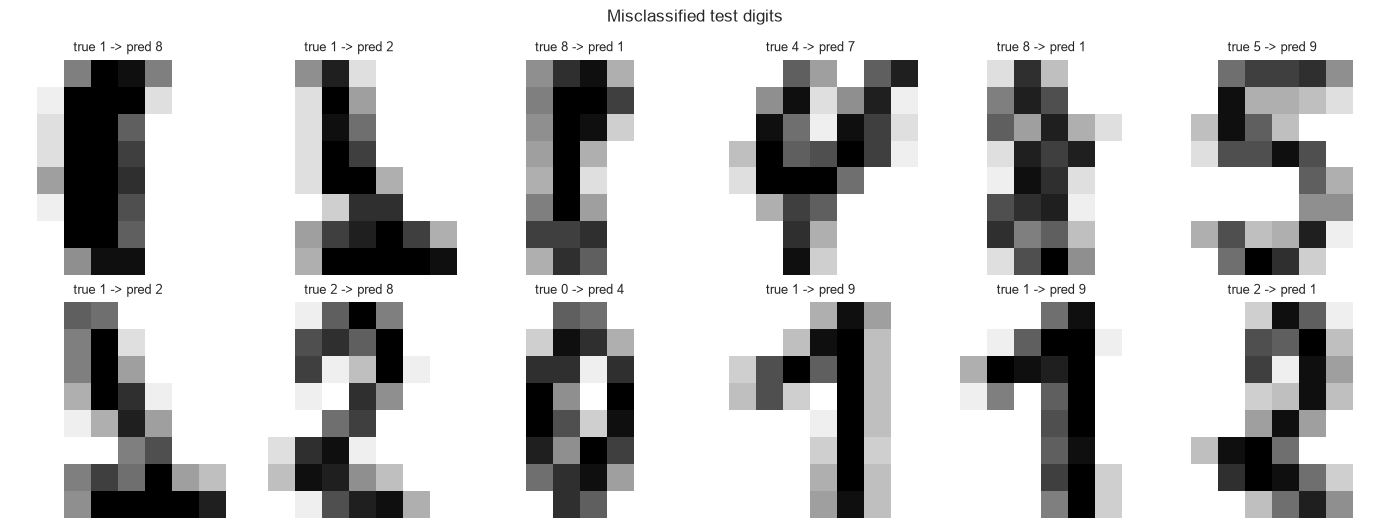

Misclassified test images: 53 of 450

💡 The confusion matrix shows which digit pairs NB mixes up (the handwriting-shaped ones, as
   always). Check whether a human would have made the same call — a useful reality check on
   any accuracy number.


In [23]:
pred_d_nb = nb_multin_d.predict(Xd_te_nb)
cm_d_nb = confusion_matrix(yd_te_nb, pred_d_nb)

fig, axes = plt.subplots(1, 2, figsize=(17, 6.5))
sns.heatmap(cm_d_nb, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("MultinomialNB confusion matrix (rows = true digit)")
axes[0].set_xlabel("predicted digit")
axes[0].set_ylabel("true digit")

per_digit_nb = [accuracy_score(yd_te_nb[yd_te_nb == d], pred_d_nb[yd_te_nb == d]) for d in range(10)]
axes[1].bar(range(10), per_digit_nb, color="#9467bd")
axes[1].set_ylim(0.4, 1.02)
axes[1].set_xticks(range(10))
axes[1].set_xlabel("digit")
axes[1].set_ylabel("accuracy")
axes[1].set_title("Per-digit accuracy (MultinomialNB)")
plt.tight_layout()
plt.show()

wrong_nb = np.flatnonzero(pred_d_nb != yd_te_nb)[:12]
fig2, axes2 = plt.subplots(2, 6, figsize=(14, 5.5))
for ax_m, pos_m in zip(axes2.ravel(), wrong_nb):
    ax_m.imshow(digits_nb.images[idx_te_nb[pos_m]], cmap="gray_r")
    ax_m.set_title(f"true {yd_te_nb[pos_m]} -> pred {pred_d_nb[pos_m]}", fontsize=9)
    ax_m.axis("off")
for ax_m in axes2.ravel()[len(wrong_nb):]:
    ax_m.axis("off")
fig2.suptitle("Misclassified test digits")
plt.tight_layout()
plt.show()

print(f"Misclassified test images: {len(np.flatnonzero(pred_d_nb != yd_te_nb))} of {len(yd_te_nb)}")
print("\n💡 The confusion matrix shows which digit pairs NB mixes up (the handwriting-shaped ones, as")
print("   always). Check whether a human would have made the same call — a useful reality check on")
print("   any accuracy number.")

---

## 11. Comparison with Other Algorithms

### When to Choose Naive Bayes vs Alternatives

| Aspect | Gaussian NB | Logistic Regression | Decision Tree | Random Forest | SVM (RBF) | KNN |
|---|---|---|---|---|---|---|
| **Interpretability** | ⭐⭐⭐ (word log-odds) | ⭐⭐⭐⭐⭐ (odds ratios) | ⭐⭐⭐⭐ (visual) | ⭐⭐ | ⭐ (support vectors) | ⭐⭐ |
| **Training Speed** | ⭐⭐⭐⭐⭐ (one pass) | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐⭐ |
| **Prediction Speed** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| **Non-linear Boundaries** | ⭐⭐⭐ (quadratic) | ⭐ (transform-fixable) | ⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Probability Quality** | ⭐⭐⭐ (overconfident under dependence) | ⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐ (needs calibration) | ⭐⭐ |
| **Feature Scaling Needed** | ❌ | ✅ (for speed) | ❌ | ❌ | ✅ | ✅ |
| **Small Data** | ⭐⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐⭐⭐ | ⭐⭐⭐⭐ |
| **Sparse High-dimensional** | ⭐⭐⭐⭐⭐ (Multinomial) | ⭐⭐⭐⭐ | ⭐⭐ | ⭐⭐ | ⭐⭐⭐⭐ (linear kernel) | ⭐⭐ |
| **Streaming (partial_fit)** | ✅ (sklearn) | ❌ | ❌ | ❌ | ❌ | ❌ |

The **training-speed, small-data and sparse rows** are where NB earns its place. The **probability-quality row** is its recurring cost: exact arithmetic on a wrong (independent) model. The **non-linear row** is capped at quadratic — Gaussian NB can bend boundaries, but only into conic sections.

### Practical Comparison

The same CV protocol as notebook 05 on three geometries: blobs (separable), moons (interleaved), and the real breast cancer data. Every model sees the same scaled features where scaling matters; GaussianNB runs raw, because scaling is not its lever.

ALGORITHM COMPARISON: 5-FOLD CV ACCURACY ON THREE GEOMETRIES
Dataset              Blobs (separable)  Breast cancer (real)  Moons (interleaved)
Algorithm                                                                        
Gaussian NB                      0.960                0.9385                0.852
KNN (k=7)                        0.968                0.9649                0.966
Linear SVC                       0.962                0.9666                0.858
Logistic Regression              0.960                0.9737                0.860
RBF SVM (SVC)                    0.960                0.9772                0.958
Random Forest                    0.962                0.9543                0.962


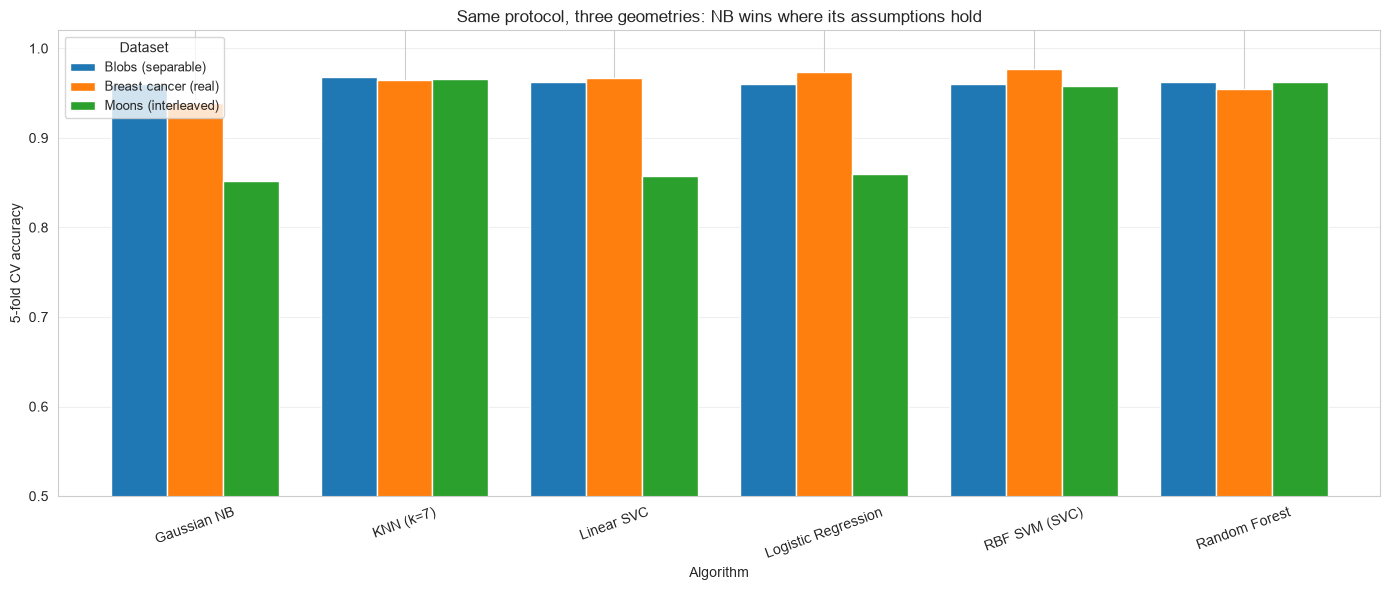


💡 On separable Gaussian blobs NB sits at or near the top — blobs are literally the model's own
   class. On the interleaved moons it pays for the independence geometry. Check the real-data
   column before generalizing any of it to production problems.


In [24]:
bc_cmp_nb = load_breast_cancer()
datasets_cmp = {
    "Blobs (separable)": make_blobs(n_samples=500, centers=2, cluster_std=2.8, random_state=42),
    "Moons (interleaved)": make_moons(n_samples=500, noise=0.22, random_state=42),
    "Breast cancer (real)": (bc_cmp_nb.data, bc_cmp_nb.target),
}


def cmp_estimators_nb():
    return {
        "Gaussian NB": GaussianNB(),
        "Logistic Regression": Pipeline([("sc", StandardScaler()),
                                         ("clf", LogisticRegression(max_iter=2000))]),
        "Linear SVC": Pipeline([("sc", StandardScaler()),
                                ("clf", LinearSVC(max_iter=5000))]),
        "RBF SVM (SVC)": Pipeline([("sc", StandardScaler()),
                                   ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))]),
        "KNN (k=7)": Pipeline([("sc", StandardScaler()),
                               ("clf", KNeighborsClassifier(n_neighbors=7))]),
        "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    }


rows_bench = []
cv_bench = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for dname_b, (Xd_b, yd_b) in datasets_cmp.items():
    for ename_b, est_b in cmp_estimators_nb().items():
        t0 = time.perf_counter()
        scores_b = cross_val_score(est_b, Xd_b, yd_b, cv=cv_bench, scoring="accuracy", n_jobs=-1)
        t_b = time.perf_counter() - t0
        rows_bench.append({"Dataset": dname_b, "Algorithm": ename_b,
                           "CV accuracy": scores_b.mean(), "± std": scores_b.std(),
                           "CV time (s)": t_b})
bench_df = pd.DataFrame(rows_bench)

pivot_bench = bench_df.pivot(index="Algorithm", columns="Dataset", values="CV accuracy")
print("=" * 60)
print("ALGORITHM COMPARISON: 5-FOLD CV ACCURACY ON THREE GEOMETRIES")
print("=" * 60)
print(pivot_bench.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
pivot_bench.plot(kind="bar", ax=ax, rot=20, width=0.8)
ax.set_ylabel("5-fold CV accuracy")
ax.set_ylim(0.5, 1.02)
ax.set_title("Same protocol, three geometries: NB wins where its assumptions hold")
ax.legend(title="Dataset", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 On separable Gaussian blobs NB sits at or near the top — blobs are literally the model's own")
print("   class. On the interleaved moons it pays for the independence geometry. Check the real-data")
print("   column before generalizing any of it to production problems.")

---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - **Bayes, T. (1763). "An Essay towards Solving a Problem in the Doctrine of Chances."** *Philosophical Transactions of the Royal Society*, 53: the theorem underneath everything
   - **John, G. H., & Langley, P. (1995). "Estimating Continuous Distributions in Bayesian Classifiers."** *UAI '95*: the per-feature Gaussian estimation behind `GaussianNB`
2. **Why it works despite the assumption**:
   - **Domingos, P., & Pazzani, M. (1997). "On the Optimality of the Simple Bayesian Classifier under Zero-One Loss."** *Machine Learning*, 29: decisions survive dependence even when probabilities do not
   - Rish, I. (2001). "An Empirical Study of the Naive Bayes Classifier." *IJCAI 2001 Workshop on Empirical Methods in AI*
   - Zhang, H. (2004). "The Optimality of Naive Bayes." *FLAIRS 2004*
3. **Text classification**:
   - **McCallum, A., & Nigam, K. (1998). "A Comparison of Event Models for Naive Bayes Text Classification."** *AAAI/ICML-98 Workshop on Learning for Text Categorization*: the multinomial-vs-Bernoulli comparison behind §6
   - Rennie, J. D. M., Shih, L., Teevan, J., & Karger, D. R. (2003). "Tackling the Poor Assumptions of Naive Bayes Text Classifiers." *ICML 2003*: the motivation behind `ComplementNB`
4. **Modern Textbooks**:
   - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*, Chapter 4 (probabilistic generative models)
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*, Chapter 6 (naive Bayes as a kernel-density/normal special case)
   - Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*, MIT Press — generative classifiers and discrete-data models
   - Mitchell, T. M. (1997). *Machine Learning*, Chapter 6 (Bayesian learning, including the classic MAP/MLE derivation)

### 🌐 Online Resources

- [Scikit-learn Naive Bayes user guide](https://scikit-learn.org/stable/modules/naive_bayes.html): the five variants and their regimes
- [GaussianNB API reference](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)
- [MultinomialNB API reference](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)
- [Working with text data guide](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction): `CountVectorizer` to `MultinomialNB`, end to end
- StatQuest's Naive Bayes videos on YouTube (search "StatQuest naive bayes"): the intuition for the independence assumption

### 📊 Key Concepts to Master

- **Bayes' rule and MAP**: the denominator drops out; the decision needs only prior × likelihood
- **Conditional independence**: $P(x \mid c) = \prod_j P(x_j \mid c)$ — the entire trick, and the entire risk
- **Log space**: sum log densities, normalise by subtracting the row max (logsumexp); products of small densities underflow
- **Axis-aligned ellipses**: per-feature Gaussians mean independence geometry; correlated features bend the boundary
- **The two numerical knobs**: `var_smoothing` (Gaussian variance floor) and `alpha` (count smoothing) — same lesson, two event models
- **The priors lever**: `priors` / `class_prior` shift the boundary without touching the likelihoods
- **Accuracy vs probability quality**: dependence hurts the probabilities first, the decisions second

### 🔗 Related Notebooks and Repository Files

- `02_logistic_regression.ipynb`: the discriminative probabilistic counterpart — same linear regime, calibrated weights
- `05_support_vector_machines.ipynb`: the margin-based alternative; also explains why its dual-engine check agrees only approximately while NB's agrees exactly
- `07_k_nearest_neighbors.ipynb`: the instance-based alternative that stores every training row
- `04_random_forest.ipynb`: the assumption-free ensemble alternative
- `src/models/naive_bayes_models.py`: the from-scratch twin used in §5
- `tests/models/test_naive_bayes_models.py`: the behavioral tests pinning the twin's conventions (exact sklearn agreement, smoothing, label handling, validation)
- `app/registry/algorithms/naive_bayes.py`: the Streamlit card whose lessons this notebook extends

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: Bayes' rule + the naive independence factorisation turns density estimation into counting. The MAP decision needs only $\log \pi_c + \sum_j \log P(x_j \mid c)$
2. **Numerics**: everything happens in log space; normalisation subtracts the row max so no likelihood magnitude can overflow or underflow
3. **Geometry**: per-feature Gaussians give axis-aligned ellipse likelihood contours and quadratic decision boundaries — the independence assumption drawn
4. **Assumptions**: the variant must match the feature type; no scaling for Gaussian; counts must never be scaled; correlated features are double-counted
5. **Implementation**: the twin is ~170 readable lines: closed-form fit, log-space predict, exact agreement with sklearn to floating point
6. **Hyperparameters**: almost none — `var_smoothing` is insurance, `priors` is the imbalance lever, `alpha` smooths counts. Tuning cannot buy capacity that NB does not have
7. **Practice**: on real medical data NB's accuracy stands but its probabilities overfit their independence assumption; on digits the count event model is typically the stronger of the two; on text, the log-odds *are* the explanation

### When to Use Naive Bayes

✅ **Use when**:
- speed matters — one-pass fit, one-pass predict, tiny model, `partial_fit` for streams
- data is small — dozens of rows per class are enough
- the data is text or counts — MultinomialNB is still a serious text baseline
- you need a floor for every other model — fit it first

❌ **Avoid when**:
- calibrated probabilities are the product and features correlate — use logistic regression
- interactions carry the signal — the product of one-feature terms cannot express them
- heavy-tailed features with no transformation budget — the moments are fragile
- you need maximum accuracy on clean tabular data — boosted trees will usually beat it

### Best Practices Checklist

- ✅ match the variant to the feature type before anything else
- ✅ fit GaussianNB first and treat its score as the floor
- ✅ check the reliability diagram before consuming any probability
- ✅ drop redundant (correlated) features instead of double-counting them
- ✅ use `priors` / `class_prior` for imbalance, tuned on training CV
- ✅ transform heavy-tailed features; never scale counts
- ✅ read `feature_log_prob_` for word-level explanations on text

### Critical Requirements

1. **The right variant for the right feature type** — the single most common failure
2. **Complete data** — impute NaN/inf first; GaussianNB validates finiteness
3. **Roughly per-class unimodal features** for the Gaussian variant — or transform them
4. **Independence acknowledged** — tolerated for decisions, not for probabilities

### Advantages vs Disadvantages

**Advantages:**
- ✅ fastest classifier in the repo: one-pass fit, one-pass predict
- ✅ data-efficient: works from a few dozen rows per class
- ✅ native probabilities (no calibration dance like `probability=True`)
- ✅ streaming-ready via `partial_fit` (sklearn)
- ✅ word-level interpretability for free on text

**Disadvantages:**
- ❌ probabilities systematically overconfident under feature dependence
- ❌ cannot represent feature interactions
- ❌ performance capped by the variant choice — no capacity knob to tune
- ❌ Gaussian variant fragile to skewed/heavy-tailed features
- ❌ no regressor — classification only

### Unique Characteristic: The Generative Stance

Naive Bayes does not ask "which side of the boundary is this point on?" It asks "which class's story about the data explains this point best?" — and it stores that story, so you can sample from it, inspect it word by word, and update it incrementally. The cost of the story is the independence assumption; the benefit is everything above.

### Next Steps

1. **Practice** on your own data: fit GaussianNB raw, note its score, and make every subsequent model beat it
2. **Diagnose**: reliability diagrams for probabilities, per-class histograms for distribution fit, correlations for double-counting
3. **Compare** with logistic regression on the same features — the honest test of whether dependence is hurting you (§11 style)
4. **Read** notebook 02 for the discriminative counterpart and notebook 05 for the margin-based alternative
5. **Explore** `tests/models/test_naive_bayes_models.py` to see which behaviors the scratch twin pins down

---

**Congratulations!** You can now derive the MAP rule, explain why NB lives in log space, rebuild its posteriors by hand, and know which event model your features demand. 🎯🎉

**Remember**: the independence assumption costs you probabilities before it costs you decisions. Match the variant to the feature type, check the calibration, and let NB be the honest baseline the rest of your stack has to beat.